In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel, Person

In [6]:
def inspect_state(model, step_num):
    print(f"--- Step {step_num} ---")
    for a in model.agents:
        # Correctly parses the ("OPERATOR", [var1, var2]) structure
        kb_str = ", ".join([f"{c[0]}({c[1][0]},{c[1][1]})" for c in a.kb])
        print(f"Agent {a.unique_id} | Bits: {a.x} | True V: {a.true_violations} | KB Size: {len(a.kb)} | KB: [{kb_str}]")

In [17]:
import networkx as nx

# 1. Create an isolated node with a self-loop
G1 = nx.DiGraph()
G1.add_node(0)
G1.add_edge(0, 0) 

# 2. Instantiate the model
model1 = ProblemSolvingModel(setup_source="graph", input_graph=G1, kb_fraction=1.0, seed=42)

# 3. Freeze the environment and set 1-based clauses
model1.K = 2
model1.M = 1
model1.clause_interval = 999999  
model1.C = [("AND", (1, 2))]     

# 4. Manually override the agent's state AND local obs pool
agent = model1.agents[0]
agent.x = [0, 0]             
agent.kb = [("AND", (1, 2))]  
agent.local_obs_pool = list(model1.C)  # <-- The missing link!
model1.calc_performances()

# 5. Run and Inspect
print("TEST 1: The Solitary Brain")
inspect_state(model1, 0)
for t in range(1, 10):
    model1.step()
    inspect_state(model1, t)

TEST 1: The Solitary Brain
--- Step 0 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 1 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 2 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 3 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 4 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 5 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 6 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 7 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 8 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 9 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]


In [22]:
import networkx as nx

# 1. Create an isolated node with a self-loop
G1 = nx.DiGraph()
G1.add_node(0)
G1.add_edge(0, 0) 

# 2. Instantiate the model
model1 = ProblemSolvingModel(setup_source="graph", input_graph=G1, kb_fraction=1.0, seed=42)

# 3. Freeze the environment and set 1-based clauses
model1.K = 2
model1.M = 1
model1.clause_interval = 999999  
model1.C = [("AND", (1, 2))]     

# 4. Manually override the agent's state AND local obs pool
agent = model1.agents[0]
agent.x = [0, 0]             
agent.kb = [("AND", (1, 2))]  
agent.local_obs_pool = list(model1.C)  # <-- The missing link!
model1.calc_performances()

# 5. Run and Inspect
print("TEST 1: The Solitary Brain")
inspect_state(model1, 0)
for t in range(1, 10):
    model1.step()
    # THE PROACTIVE REFLECTION PATCH
    for a in model1.agents:
        for c in a.kb:
            a.local_update_around(c)
    inspect_state(model1, t)

TEST 1: The Solitary Brain
--- Step 0 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 1 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 2 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 3 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 4 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 5 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 6 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 7 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 8 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 9 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]


In [21]:
# 1. Create a directed graph with self-loops
G2 = nx.DiGraph()
G2.add_edges_from([(0, 1), (0, 0), (1, 1)]) 

# 2. Instantiate model with ZERO initial knowledge
model2 = ProblemSolvingModel(setup_source="graph", input_graph=G2, kb_fraction=0.0, seed=10)

# 3. Freeze environment and override formula
model2.K = 2
model2.M = 1
model2.clause_interval = 999999
model2.C = [("AND", (1, 2))]

# 4. Setup Master (0) and Apprentice (1)
for a in model2.agents:
    a.local_obs_pool = list(model2.C)  # Sterilize observation pools

master = model2.agents[0]
apprentice = model2.agents[1]

master.x = [1, 1]
master.kb = [("AND", (1, 2))]  

apprentice.x = [0, 0]
apprentice.kb = []             

model2.calc_performances()

# 5. Run and Inspect
print("\nTEST 2: The Master and Apprentice")
inspect_state(model2, 0)
for t in range(1, 6):
    model2.step()
    inspect_state(model2, t)


TEST 2: The Master and Apprentice
--- Step 0 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 0 | KB: []
--- Step 1 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 2 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 3 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 4 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 5 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]


In [24]:
# 1. Create a complete triangle network 
G3 = nx.complete_graph(3)

# 2. Instantiate model with perfect knowledge
model3 = ProblemSolvingModel(setup_source="graph", input_graph=G3, kb_fraction=1.0, seed=99)

# 3. Freeze environment and inject the frustrated 1-based XOR loop
model3.K = 3
model3.M = 3
model3.clause_interval = 999999
model3.C = [("XOR", (1, 2)), ("XOR", (2, 3)), ("XOR", (3, 1))]

# 4. Sync agent knowledge AND observation pool to the new formula
for a in model3.agents:
    a.kb = list(model3.C)
    a.local_obs_pool = list(model3.C)  # Sterilize observation pools
    a.x = [0, 0, 0]  

model3.calc_performances()

# 5. Run and Inspect
print("\nTEST 3: The Frustrated Loop")
inspect_state(model3, 0)
for t in range(1, 60):
    model3.step()
    # THE PROACTIVE REFLECTION PATCH
    for a in model3.agents:
        for c in a.kb:
            a.local_update_around(c)
    inspect_state(model3, t)


TEST 3: The Frustrated Loop
--- Step 0 ---
Agent 0 | Bits: [0, 0, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 0, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 2 | Bits: [0, 0, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
--- Step 1 ---
Agent 0 | Bits: [0, 1, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 1, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 2 | Bits: [0, 1, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
--- Step 2 ---
Agent 0 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 2 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
--- Step 3 ---
Agent 0 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 1, 0] | Tru

TEST 4: The Hub Advantage (Star Graph, Low Memory)
Simulating...
Simulation Complete. Plotting results...


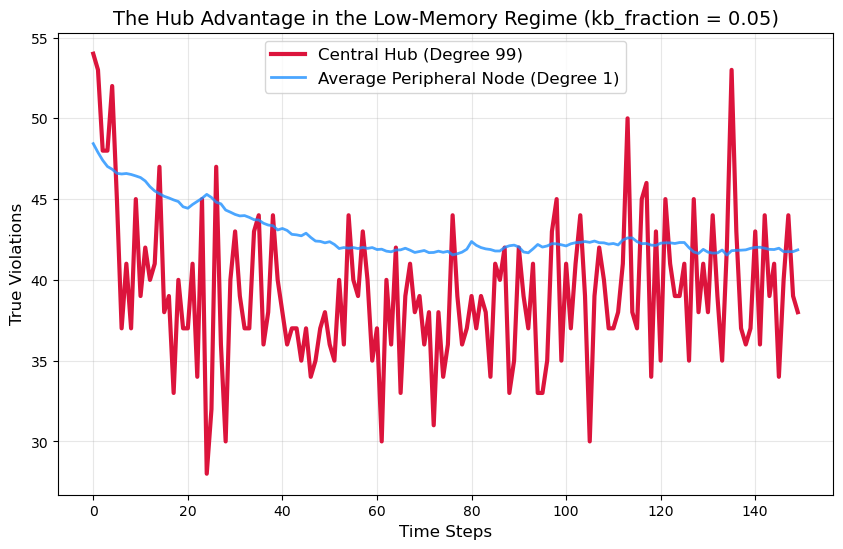

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a Star Graph (1 Hub, 99 Peripheral nodes)
N = 100
G_star = nx.star_graph(N - 1)

# Ensure math safety with self-loops
for i in range(N):
    G_star.add_edge(i, i)

# 2. Instantiate the model in the Low-Memory Regime
model_star = ProblemSolvingModel(
    setup_source="graph", 
    input_graph=G_star, 
    kb_fraction=0.05,  # Severely restricted memory! (5% of clauses)
    seed=101
)

# Note: We do NOT freeze the environment this time. 
# We want the full 100-variable, 100-clause problem to see the statistical advantage.

# 3. Data Collection Setup
steps = 150
hub_violations = []
periphery_violations = []

print("TEST 4: The Hub Advantage (Star Graph, Low Memory)")
print("Simulating...")

# 4. Run the simulation
for t in range(steps):
    model_star.step()
    
    # THE PROACTIVE REFLECTION PATCH
    # (Ensuring agents actively use the information they receive)
    for a in model_star.agents:
        for c in a.kb:
            a.local_update_around(c)
            
    # Collect Data
    # Node 0 is always the center of a networkx star_graph
    hub_v = model_star.agents[0].true_violations
    
    # Nodes 1 through N-1 are the periphery
    periph_v = np.mean([a.true_violations for a in model_star.agents[1:]])
    
    hub_violations.append(hub_v)
    periphery_violations.append(periph_v)

print("Simulation Complete. Plotting results...")

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(hub_violations, label=f"Central Hub (Degree {N-1})", color="crimson", linewidth=3)
plt.plot(periphery_violations, label="Average Peripheral Node (Degree 1)", color="dodgerblue", alpha=0.8, linewidth=2)

# Formatting the plot
plt.title("The Hub Advantage in the Low-Memory Regime (kb_fraction = 0.05)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Running 50 ensemble simulations...
Averaging complete. Plotting...


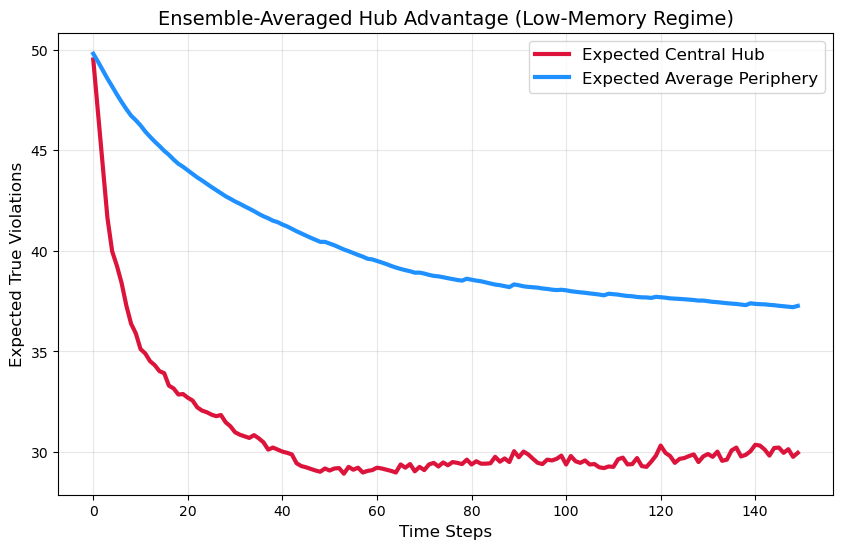

In [37]:
# --- ENSEMBLE AVERAGED STAR GRAPH ---
N = 100
steps = 150
num_runs = 50 # Average over 50 distinct runs to wash out the noise

# Matrices to store the trajectories for every run
all_hub_v = np.zeros((num_runs, steps))
all_periph_v = np.zeros((num_runs, steps))

print(f"Running {num_runs} ensemble simulations...")

for run in range(num_runs):
    G_star = nx.star_graph(N - 1)
    for i in range(N): G_star.add_edge(i, i)
        
    model = ProblemSolvingModel(
        setup_source="graph", 
        input_graph=G_star, 
        kb_fraction=0.75, 
        seed=run # Change the seed for every run!
    )
    
    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
                
        all_hub_v[run, t] = model.agents[0].true_violations
        all_periph_v[run, t] = np.mean([a.true_violations for a in model.agents[1:]])

print("Averaging complete. Plotting...")

# Calculate the mean across all runs for each time step
mean_hub = np.mean(all_hub_v, axis=0)
mean_periph = np.mean(all_periph_v, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_hub, label=f"Expected Central Hub", color="crimson", linewidth=3)
plt.plot(mean_periph, label="Expected Average Periphery", color="dodgerblue", linewidth=3)

plt.title("Ensemble-Averaged Hub Advantage (Low-Memory Regime)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Expected True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. BA Network & Simulation Parameters
N = 100
m = 2          # Number of edges to attach from a new node to existing nodes
steps = 10000
num_runs = 50  # 50 runs to match your excellent smoothing

# Matrices to store the trajectory sums (to average later)
hist_hubs = np.zeros((num_runs, steps))
hist_mid = np.zeros((num_runs, steps))
hist_periph = np.zeros((num_runs, steps))

print(f"Running {num_runs} ensemble simulations on Scale-Free Networks...")

# 2. Run the Ensemble
for run in range(num_runs):
    # Generate a new BA graph for every run
    G_BA = nx.barabasi_albert_graph(N, m, seed=run+5)
    for i in range(N): G_BA.add_edge(i, i) # Self-loops for math safety
        
    model = ProblemSolvingModel(
        setup_source="graph", 
        input_graph=G_BA, 
        kb_fraction=0.05, 
        seed=run
    )
    
    # Dynamically categorize nodes based on this specific run's degree distribution
    degrees = dict(G_BA.degree())
    # Note: Because of the self-loop, minimum degree is m+1 (which is 3)
    periph_nodes = [n for n, d in degrees.items() if d <= 4]
    hub_nodes = [n for n, d in degrees.items() if d >= 12]
    mid_nodes = [n for n, d in degrees.items() if 4 < d < 12]
    
    for t in range(steps):
        model.step()
        
        # Proactive Reflection Patch
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
                
        # Record the mean violations for each class at this time step
        hist_hubs[run, t] = np.mean([model.agents[n].true_violations for n in hub_nodes]) if hub_nodes else 0
        hist_mid[run, t] = np.mean([model.agents[n].true_violations for n in mid_nodes]) if mid_nodes else 0
        hist_periph[run, t] = np.mean([model.agents[n].true_violations for n in periph_nodes]) if periph_nodes else 0

print("Simulation Complete. Plotting...")

# 3. Average across all runs
mean_hubs = np.mean(hist_hubs, axis=0)
mean_mid = np.mean(hist_mid, axis=0)
mean_periph = np.mean(hist_periph, axis=0)



Running 50 ensemble simulations on Scale-Free Networks...
Simulation Complete. Plotting...


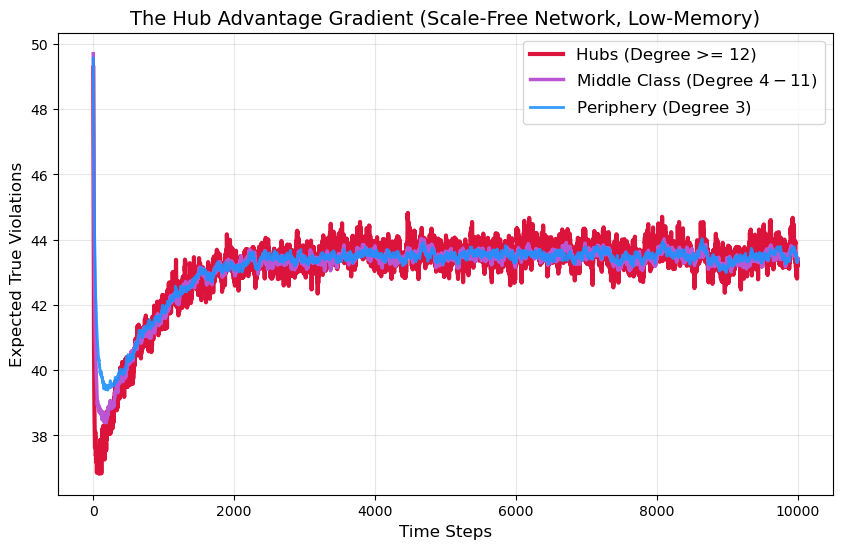

In [4]:
# 4. Plot the Hierarchy
plt.figure(figsize=(10, 6))

plt.plot(mean_hubs, label="Hubs (Degree >= 12)", color="crimson", linewidth=3)
plt.plot(mean_mid, label="Middle Class (Degree $4 - 11$)", color="mediumorchid", linewidth=2.5)
plt.plot(mean_periph, label="Periphery (Degree $3$)", color="dodgerblue", linewidth=2, alpha=0.9)

plt.title("The Hub Advantage Gradient (Scale-Free Network, Low-Memory)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Expected True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. BA Network & Simulation Parameters
N = 100
m = 2          # Number of edges to attach from a new node to existing nodes
steps = 150
num_runs = 50  # 50 runs to match your excellent smoothing

# Matrices to store the trajectory sums (to average later)
hist_hubs = np.zeros((num_runs, steps))
hist_mid = np.zeros((num_runs, steps))
hist_periph = np.zeros((num_runs, steps))

print(f"Running {num_runs} ensemble simulations on Scale-Free Networks...")

# 2. Run the Ensemble
for run in range(num_runs):
    # Generate a new BA graph for every run
    G_BA = nx.barabasi_albert_graph(N, m, seed=run+5)
    for i in range(N): G_BA.add_edge(i, i) # Self-loops for math safety
        
    model = ProblemSolvingModel(
        setup_source="graph", 
        input_graph=G_BA, 
        kb_fraction=0.75, 
        seed=run
    )
    
    # Dynamically categorize nodes based on this specific run's degree distribution
    degrees = dict(G_BA.degree())
    # Note: Because of the self-loop, minimum degree is m+1 (which is 3)
    periph_nodes = [n for n, d in degrees.items() if d <= 4]
    hub_nodes = [n for n, d in degrees.items() if d >= 12]
    mid_nodes = [n for n, d in degrees.items() if 4 < d < 12]
    
    for t in range(steps):
        model.step()
        
        # Proactive Reflection Patch
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
                
        # Record the mean violations for each class at this time step
        hist_hubs[run, t] = np.mean([model.agents[n].true_violations for n in hub_nodes]) if hub_nodes else 0
        hist_mid[run, t] = np.mean([model.agents[n].true_violations for n in mid_nodes]) if mid_nodes else 0
        hist_periph[run, t] = np.mean([model.agents[n].true_violations for n in periph_nodes]) if periph_nodes else 0

print("Simulation Complete. Plotting...")

# 3. Average across all runs
mean_hubs = np.mean(hist_hubs, axis=0)
mean_mid = np.mean(hist_mid, axis=0)
mean_periph = np.mean(hist_periph, axis=0)



Running 50 ensemble simulations on Scale-Free Networks...
Simulation Complete. Plotting...


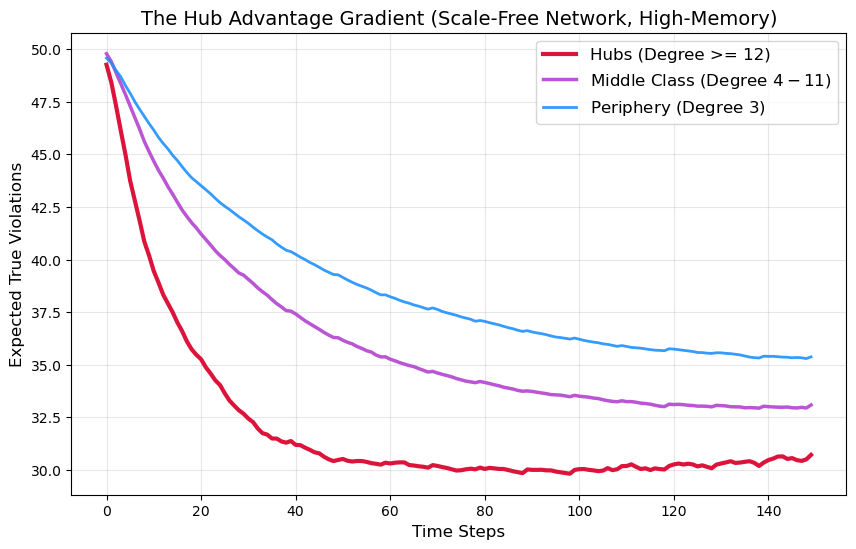

In [41]:
# 4. Plot the Hierarchy
plt.figure(figsize=(10, 6))

plt.plot(mean_hubs, label="Hubs (Degree >= 12)", color="crimson", linewidth=3)
plt.plot(mean_mid, label="Middle Class (Degree $4 - 11$)", color="mediumorchid", linewidth=2.5)
plt.plot(mean_periph, label="Periphery (Degree $3$)", color="dodgerblue", linewidth=2, alpha=0.9)

plt.title("The Hub Advantage Gradient (Scale-Free Network, High-Memory)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Expected True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
import numpy as np
from scipy.stats import poisson
from scipy.optimize import root_scalar

alpha = 4.0

def prob_Y_gt_X1(p, alpha):
    # Pr(Y > X1)
    # Y ~ Poisson(alpha)
    # X1 ~ Poisson(alpha * p)
    # sum_{k=0}^infty P(X1 = k) * P(Y >= k+1)
    # P(Y >= k+1) = 1 - P(Y <= k) = 1 - poisson.cdf(k, alpha)
    total = 0
    for k in range(50):
        total += poisson.pmf(k, alpha * p) * (1 - poisson.cdf(k, alpha))
    return total

def prob_X1_gt_Y(p, alpha):
    # Pr(X1 > Y)
    total = 0
    for k in range(50):
        total += poisson.pmf(k, alpha) * (1 - poisson.cdf(k, alpha * p))
    return total

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.99])
p_star = sol.root
v_star = 1 - p_star + (p_star**2) / 2

with open("output.csv", "w") as f:
    f.write(f"alpha,p_star,V_star\n{alpha},{p_star},{v_star}\n")
    
print(f"p* = {p_star:.4f}, V* = {v_star:.4f}")

p* = 0.7021, V* = 0.5444


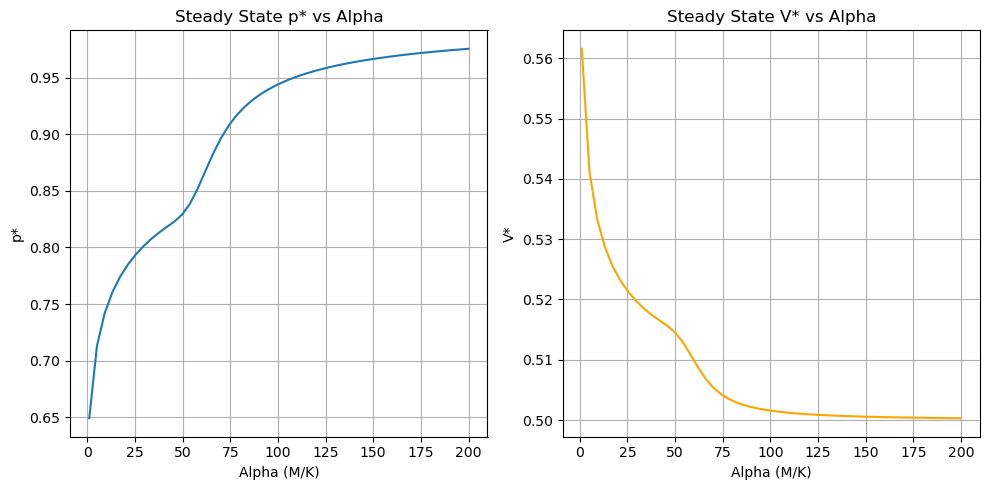

In [6]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.linspace(1, 200, 50)
p_stars = []
v_stars = []

for a in alphas:
    sol = root_scalar(dp_dt_eq, args=(a,), bracket=[0.01, 0.999])
    p = sol.root
    p_stars.append(p)
    # The mean field violation formula from the initial pdf: V = M(1 - p + p^2/2).
    # Since V is fraction of violations per clause, we divide by M: V_frac = 1 - p + p^2/2
    v_stars.append(1 - p + (p**2) / 2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(alphas, p_stars, label="p* (fraction of ones)")
plt.xlabel("Alpha (M/K)")
plt.ylabel("p*")
plt.title("Steady State p* vs Alpha")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(alphas, v_stars, label="V* (fraction of violations)", color='orange')
plt.xlabel("Alpha (M/K)")
plt.ylabel("V*")
plt.title("Steady State V* vs Alpha")
plt.grid(True)
plt.tight_layout()
#plt.savefig("equilibrium.png")
plt.show()

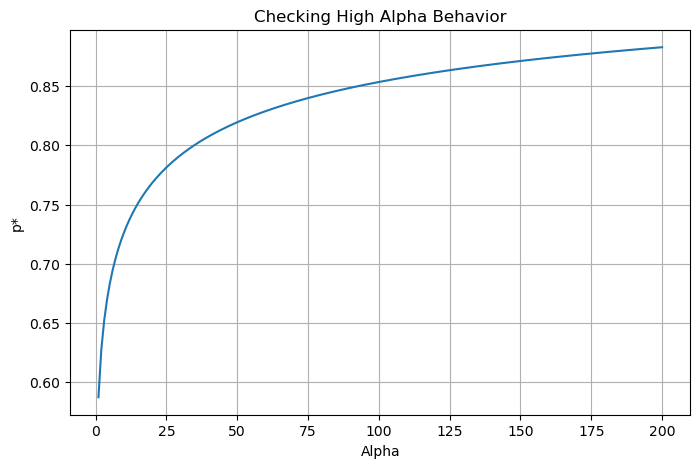

In [1]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

def prob_Y_gt_X1(p, alpha):
    # Using scipy.stats.poisson built-in vectorized methods for speed
    k = np.arange(int(alpha*3 + 100))
    # pmf array for X1 ~ Poisson(alpha * p)
    pmf_X1 = poisson.pmf(k, alpha * p)
    # P(Y > k) = 1 - P(Y <= k) where Y ~ Poisson(alpha)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1) # sf(k) = 1 - cdf(k)
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha*3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

alphas = np.linspace(1, 200, 200)
p_stars = []

for a in alphas:
    try:
        sol = root_scalar(dp_dt_eq, args=(a,), bracket=[0.01, 0.999], method='brentq')
        p_stars.append(sol.root)
    except Exception as e:
        print(f"Failed at alpha={a}: {e}")
        p_stars.append(np.nan)

p_stars = np.array(p_stars)

plt.figure(figsize=(8,5))
plt.plot(alphas, p_stars)
plt.xlabel("Alpha")
plt.ylabel("p*")
plt.title("Checking High Alpha Behavior")
plt.grid()
#plt.savefig("high_alpha.png")
#plt.close()
plt.show()

Running ensemble simulations across 7 alpha values...
Alpha  1.0 | Theory: 11.7 | Hubs: 8.5 | Periph: 9.3
Alpha  2.0 | Theory: 22.8 | Hubs: 18.2 | Periph: 20.5
Alpha  3.0 | Theory: 33.6 | Hubs: 30.3 | Periph: 30.2
Alpha  4.0 | Theory: 44.4 | Hubs: 35.2 | Periph: 37.0
Alpha  6.0 | Theory: 65.6 | Hubs: 58.0 | Periph: 59.9
Alpha  8.0 | Theory: 86.6 | Hubs: 76.0 | Periph: 77.9
Alpha 10.0 | Theory: 107.5 | Hubs: 86.3 | Periph: 92.7
Plotting absolute violation counts...


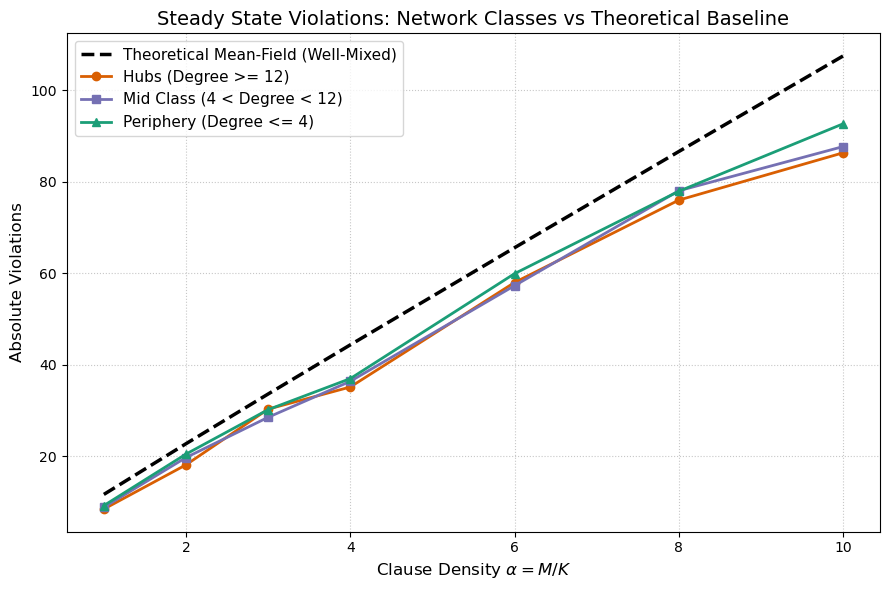

In [15]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import root_scalar
# from your_module import ProblemSolvingModel  <-- Import your model here

# ==========================================
# 1. Theoretical Poisson Equilibrium
# ==========================================
def prob_Y_gt_X1(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_X1 = poisson.pmf(k, alpha * p)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1)
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

def get_theoretical_V_absolute(alpha, K_vars):
    try:
        # 1. Find steady-state p*
        sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.999], method='brentq')
        p_star = sol.root
        
        # 2. Compute Fraction of Violations V*
        v_frac = 1 - p_star + (p_star**2) / 2
        
        # 3. Scale up to Absolute Violations (M * V*)
        M_clauses = alpha * K_vars
        return M_clauses * v_frac
    except Exception:
        return np.nan

# ==========================================
# 2. Simulation & Ensemble Parameters
# ==========================================
alphas = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0]
K_vars = 20       # Matching the default K in your code
N = 100           
m = 2             
steps = 500       
num_runs = 1

sim_hubs = []
sim_mid = []
sim_periph = []
theo_V_abs = []

print(f"Running ensemble simulations across {len(alphas)} alpha values...")

for alpha in alphas:
    M_clauses = int(alpha * K_vars)
    
    # 1. Theoretical Absolute Violations
    theo_V_abs.append(get_theoretical_V_absolute(alpha, K_vars))
    
    # Track final states for this alpha
    alpha_hubs = []
    alpha_mid = []
    alpha_periph = []
    
    for run in range(num_runs):
        G_BA = nx.barabasi_albert_graph(N, m, seed=run+5)
        for i in range(N): G_BA.add_edge(i, i)
            
        model = ProblemSolvingModel(
            N=N, K=K_vars, alpha=alpha,  # Pass dynamically
            setup_source="graph", 
            input_graph=G_BA, 
            kb_fraction=0.75, 
            seed=run
        )
        
        degrees = dict(G_BA.degree())
        periph_nodes = [n for n, d in degrees.items() if d <= 4]
        hub_nodes = [n for n, d in degrees.items() if d >= 12]
        mid_nodes = [n for n, d in degrees.items() if 4 < d < 12]
        
        for t in range(steps):
            model.step()
            for a in model.agents:
                for c in a.kb:
                    a.local_update_around(c)
                    
        # Extract final violations (index -1 corresponds to final step)
        h_v = np.mean([model.agents[n].true_violations for n in hub_nodes]) if hub_nodes else np.nan
        m_v = np.mean([model.agents[n].true_violations for n in mid_nodes]) if mid_nodes else np.nan
        p_v = np.mean([model.agents[n].true_violations for n in periph_nodes]) if periph_nodes else np.nan
        
        alpha_hubs.append(h_v)
        alpha_mid.append(m_v)
        alpha_periph.append(p_v)
        
    sim_hubs.append(np.nanmean(alpha_hubs))
    sim_mid.append(np.nanmean(alpha_mid))
    sim_periph.append(np.nanmean(alpha_periph))
    
    print(f"Alpha {alpha:4.1f} | Theory: {theo_V_abs[-1]:.1f} | Hubs: {sim_hubs[-1]:.1f} | Periph: {sim_periph[-1]:.1f}")

# ==========================================
# 3. Plotting Results
# ==========================================
print("Plotting absolute violation counts...")

plt.figure(figsize=(9, 6))

plt.plot(alphas, theo_V_abs, 'k--', label="Theoretical Mean-Field (Well-Mixed)", linewidth=2.5)

plt.plot(alphas, sim_hubs, 'o-', label="Hubs (Degree >= 12)", color='#d95f02', linewidth=2)
plt.plot(alphas, sim_mid, 's-', label="Mid Class (4 < Degree < 12)", color='#7570b3', linewidth=2)
plt.plot(alphas, sim_periph, '^-', label="Periphery (Degree <= 4)", color='#1b9e77', linewidth=2)

plt.xlabel(r"Clause Density $\alpha = M/K$", fontsize=12)
plt.ylabel(r"Absolute Violations", fontsize=12)
plt.title("Steady State Violations: Network Classes vs Theoretical Baseline", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("theory_vs_classes_absolute.png", dpi=300)
plt.show()

Running ensemble on ER Random Networks (N=50, runs=20)...
Alpha  1.0 | Theory: 11.7 | Sim (ER): 7.7
Alpha  2.0 | Theory: 22.8 | Sim (ER): 14.4
Alpha  3.0 | Theory: 33.6 | Sim (ER): 22.6
Alpha  4.0 | Theory: 44.4 | Sim (ER): 32.1
Alpha  6.0 | Theory: 65.6 | Sim (ER): 50.3
Alpha  8.0 | Theory: 86.6 | Sim (ER): 68.8
Alpha 10.0 | Theory: 107.5 | Sim (ER): 88.7
Simulation Complete. Plotting...


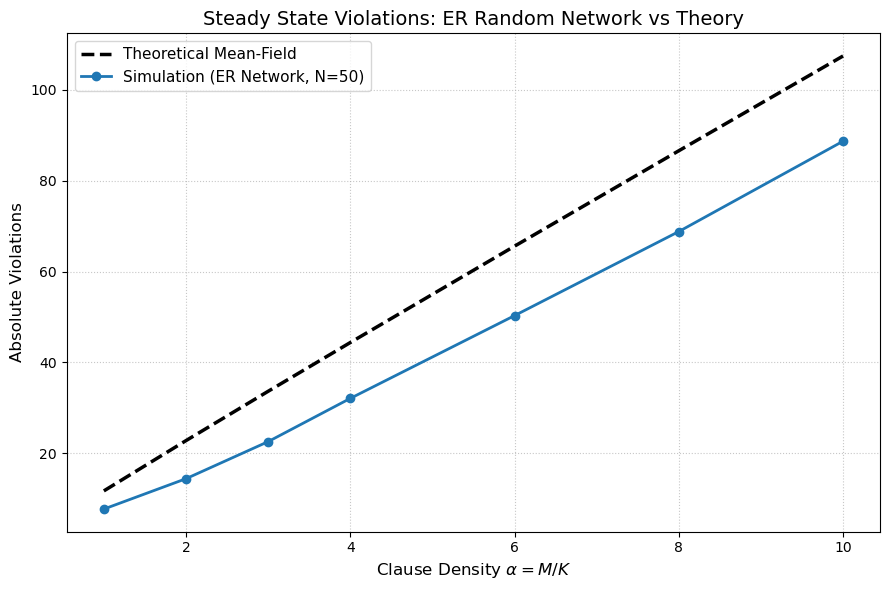

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import root_scalar
# from your_module import ProblemSolvingModel  <-- Import your model here

# ==========================================
# 1. Theoretical Poisson Equilibrium
# ==========================================
def prob_Y_gt_X1(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_X1 = poisson.pmf(k, alpha * p)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1)
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

def get_theoretical_V_absolute(alpha, K_vars):
    try:
        sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.999], method='brentq')
        p_star = sol.root
        v_frac = 1 - p_star + (p_star**2) / 2
        M_clauses = alpha * K_vars
        return M_clauses * v_frac
    except Exception:
        return np.nan

# ==========================================
# 2. Simulation & Ensemble Parameters
# ==========================================
alphas = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0]
K_vars = 20       # Binary variables
N = 50            # Reduced agents to save computation time
steps = 150       # Ticks to reach steady state
num_runs = 20     # Average over 20 runs to eliminate the noise you saw in image 64

# ER Network parameters
connect_prob = 0.2  # ~10 edges per node on average for N=50

sim_V_abs = []
theo_V_abs = []

print(f"Running ensemble on ER Random Networks (N={N}, runs={num_runs})...")

for alpha in alphas:
    M_clauses = int(alpha * K_vars)
    theo_V_abs.append(get_theoretical_V_absolute(alpha, K_vars))
    
    alpha_final_violations = []
    
    for run in range(num_runs):
        model = ProblemSolvingModel(
            N=N, K=K_vars, alpha=alpha,
            setup_source="generate",          # Use internal generator
            type_network="Random",            # Trigger setup_random_network
            connect_prob=connect_prob,        # ER edge probability
            kb_fraction=0.75, 
            seed=run
        )
        
        # Run to steady-state
        for t in range(steps):
            model.step()
            # Proactive Reflection Patch (to mirror your previous setup)
            for a in model.agents:
                for c in a.kb:
                    a.local_update_around(c)
                    
        # Extract mean final violations across all nodes in the ER graph
        v_mean = np.mean([a.true_violations for a in model.agents])
        alpha_final_violations.append(v_mean)
        
    mean_sim_V = np.mean(alpha_final_violations)
    sim_V_abs.append(mean_sim_V)
    
    print(f"Alpha {alpha:4.1f} | Theory: {theo_V_abs[-1]:.1f} | Sim (ER): {sim_V_abs[-1]:.1f}")

# ==========================================
# 3. Plotting Results
# ==========================================
print("Simulation Complete. Plotting...")

plt.figure(figsize=(9, 6))

plt.plot(alphas, theo_V_abs, 'k--', label="Theoretical Mean-Field", linewidth=2.5)
plt.plot(alphas, sim_V_abs, 'o-', label=f"Simulation (ER Network, N={N})", color='#1f77b4', linewidth=2)

plt.xlabel(r"Clause Density $\alpha = M/K$", fontsize=12)
plt.ylabel(r"Absolute Violations", fontsize=12)
plt.title("Steady State Violations: ER Random Network vs Theory", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("theory_vs_er_network.png", dpi=300)
plt.show()

Running ensemble on ER Random Networks (N=50, runs=10)...
Alpha  1.0 | Theory: 11.7 | Sim (ER): 8.7
Alpha  2.0 | Theory: 22.8 | Sim (ER): 17.2
Alpha  5.0 | Theory: 55.0 | Sim (ER): 42.7
Alpha 10.0 | Theory: 107.5 | Sim (ER): 88.1
Alpha 25.0 | Theory: 262.0 | Sim (ER): 237.7
Alpha 50.0 | Theory: 516.3 | Sim (ER): 496.3
Alpha 100.0 | Theory: 1021.5 | Sim (ER): 1007.4
Simulation Complete. Plotting...


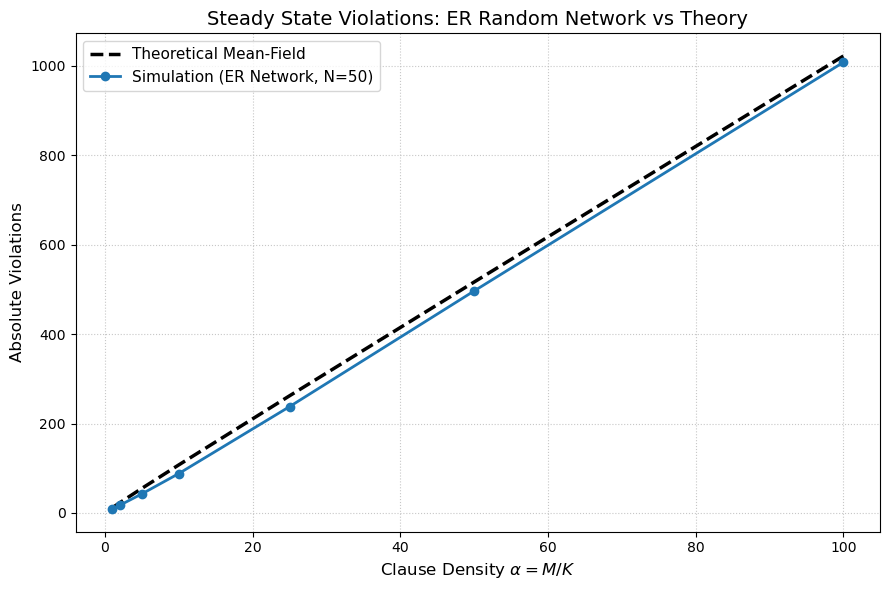

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import root_scalar
# from your_module import ProblemSolvingModel  <-- Import your model here

# ==========================================
# 1. Theoretical Poisson Equilibrium
# ==========================================
def prob_Y_gt_X1(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_X1 = poisson.pmf(k, alpha * p)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1)
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

def get_theoretical_V_absolute(alpha, K_vars):
    try:
        sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.999], method='brentq')
        p_star = sol.root
        v_frac = 1 - p_star + (p_star**2) / 2
        M_clauses = alpha * K_vars
        return M_clauses * v_frac
    except Exception:
        return np.nan

# ==========================================
# 2. Simulation & Ensemble Parameters
# ==========================================
alphas = [1.0,2.0, 5.0, 10.0,25.0, 50.0, 100.0]
K_vars = 20       # Binary variables
N = 50            # Reduced agents to save computation time
steps = 250       # Ticks to reach steady state
num_runs = 10     # Average over 20 runs to eliminate the noise you saw in image 64

# ER Network parameters
connect_prob = 0.2  # ~10 edges per node on average for N=50

sim_V_abs = []
theo_V_abs = []

print(f"Running ensemble on ER Random Networks (N={N}, runs={num_runs})...")

for alpha in alphas:
    M_clauses = int(alpha * K_vars)
    theo_V_abs.append(get_theoretical_V_absolute(alpha, K_vars))
    
    alpha_final_violations = []
    
    for run in range(num_runs):
        model = ProblemSolvingModel(
            N=N, K=K_vars, alpha=alpha,
            setup_source="generate",          # Use internal generator
            type_network="Random",            # Trigger setup_random_network
            connect_prob=connect_prob,        # ER edge probability
            kb_fraction=0.75, 
            seed=run
        )
        
        # Run to steady-state
        for t in range(steps):
            model.step()
            # Proactive Reflection Patch (to mirror your previous setup)
            for a in model.agents:
                for c in a.kb:
                    a.local_update_around(c)
                    
        # Extract mean final violations across all nodes in the ER graph
        v_mean = np.mean([a.true_violations for a in model.agents])
        alpha_final_violations.append(v_mean)
        
    mean_sim_V = np.mean(alpha_final_violations)
    sim_V_abs.append(mean_sim_V)
    
    print(f"Alpha {alpha:4.1f} | Theory: {theo_V_abs[-1]:.1f} | Sim (ER): {sim_V_abs[-1]:.1f}")

# ==========================================
# 3. Plotting Results
# ==========================================
print("Simulation Complete. Plotting...")

plt.figure(figsize=(9, 6))

plt.plot(alphas, theo_V_abs, 'k--', label="Theoretical Mean-Field", linewidth=2.5)
plt.plot(alphas, sim_V_abs, 'o-', label=f"Simulation (ER Network, N={N})", color='#1f77b4', linewidth=2)

plt.xlabel(r"Clause Density $\alpha = M/K$", fontsize=12)
plt.ylabel(r"Absolute Violations", fontsize=12)
plt.title("Steady State Violations: ER Random Network vs Theory", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("theory_vs_er_network.png", dpi=300)
plt.show()

In [32]:
alphas=range(1,1000)
alphas = np.linspace(1, 200, 200)
theo_V_abs=[]
for alpha in alphas:
    M_clauses = int(alpha * K_vars)
    sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.999], method='brentq')
    p_star = sol.root
    theo_V_abs.append(p_star)
    #theo_V_abs.append(get_theoretical_V_absolute(alpha, K_vars))

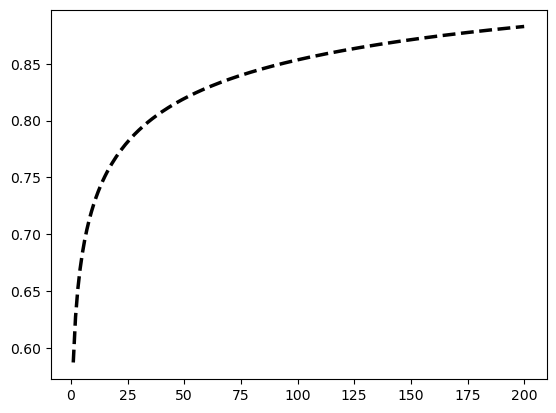

In [33]:
plt.plot(alphas, np.array(theo_V_abs), 'k--', label="Theoretical Mean-Field", linewidth=2.5)


In [37]:
alphas = [1.0,2.0, 5.0, 10.0,25.0, 50.0, 100.0]
np.array(sim_V_abs)/np.array(alpha*K_vars)

array([0.0021835, 0.004301 , 0.0106715, 0.022031 , 0.0594345, 0.1240835,
       0.2518605])

Running ensemble on ER Random Networks (N=50, runs=1)...
Alpha 100.0 | Theory: 1021.5 | Sim (ER): 1005.1
Alpha 200.0 | Theory: 2027.5 | Sim (ER): 2045.1
Alpha 500.0 | Theory: 5036.6 | Sim (ER): 5146.8
Simulation Complete. Plotting...


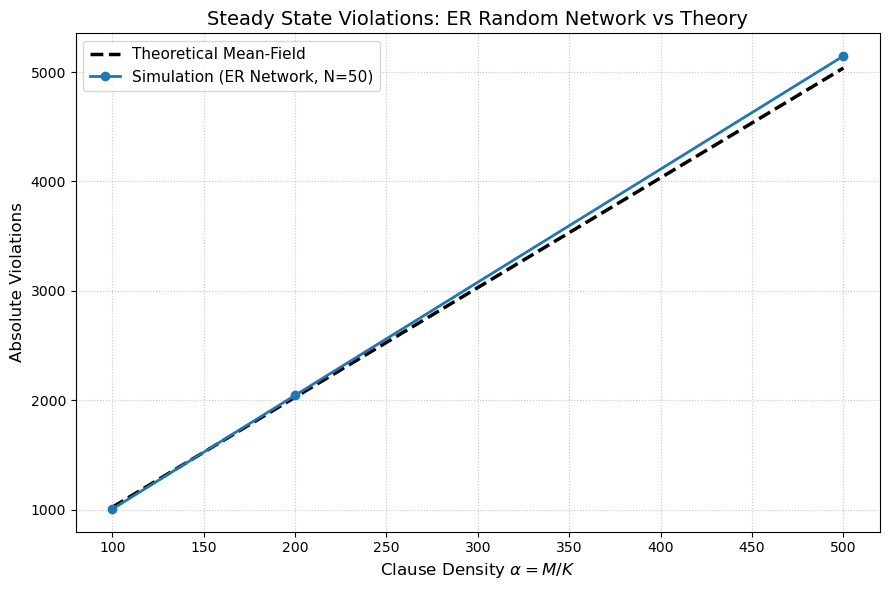

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import root_scalar

# ==========================================
# 1. Theoretical Poisson Equilibrium
# ==========================================
def prob_Y_gt_X1(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_X1 = poisson.pmf(k, alpha * p)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1)
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

def get_theoretical_V_absolute(alpha, K_vars):
    try:
        sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.999], method='brentq')
        p_star = sol.root
        v_frac = 1 - p_star + (p_star**2) / 2
        M_clauses = alpha * K_vars
        return M_clauses * v_frac
    except Exception:
        return np.nan

# ==========================================
# 2. Simulation & Ensemble Parameters
# ==========================================
alphas = [100.0,200,500]
K_vars = 20       # Binary variables
N = 50            # Reduced agents to save computation time
steps = 250       # Ticks to reach steady state
num_runs = 1     # Average over 20 runs to eliminate the noise you saw in image 64

# ER Network parameters
connect_prob = 0.2  # ~10 edges per node on average for N=50

sim_V_abs = []
theo_V_abs = []

print(f"Running ensemble on ER Random Networks (N={N}, runs={num_runs})...")

for alpha in alphas:
    M_clauses = int(alpha * K_vars)
    theo_V_abs.append(get_theoretical_V_absolute(alpha, K_vars))
    
    alpha_final_violations = []
    
    for run in range(num_runs):
        model = ProblemSolvingModel(
            N=N, K=K_vars, alpha=alpha,
            setup_source="generate",          # Use internal generator
            type_network="Random",            # Trigger setup_random_network
            connect_prob=connect_prob,        # ER edge probability
            kb_fraction=0.75, 
            seed=run
        )
        
        # Run to steady-state
        for t in range(steps):
            model.step()
            # Proactive Reflection Patch (to mirror your previous setup)
            for a in model.agents:
                for c in a.kb:
                    a.local_update_around(c)
                    
        # Extract mean final violations across all nodes in the ER graph
        v_mean = np.mean([a.true_violations for a in model.agents])
        alpha_final_violations.append(v_mean)
        
    mean_sim_V = np.mean(alpha_final_violations)
    sim_V_abs.append(mean_sim_V)
    
    print(f"Alpha {alpha:4.1f} | Theory: {theo_V_abs[-1]:.1f} | Sim (ER): {sim_V_abs[-1]:.1f}")

# ==========================================
# 3. Plotting Results
# ==========================================
print("Simulation Complete. Plotting...")

plt.figure(figsize=(9, 6))

plt.plot(alphas, theo_V_abs, 'k--', label="Theoretical Mean-Field", linewidth=2.5)
plt.plot(alphas, sim_V_abs, 'o-', label=f"Simulation (ER Network, N={N})", color='#1f77b4', linewidth=2)

plt.xlabel(r"Clause Density $\alpha = M/K$", fontsize=12)
plt.ylabel(r"Absolute Violations", fontsize=12)
plt.title("Steady State Violations: ER Random Network vs Theory", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("theory_vs_er_network.png", dpi=300)
plt.show()

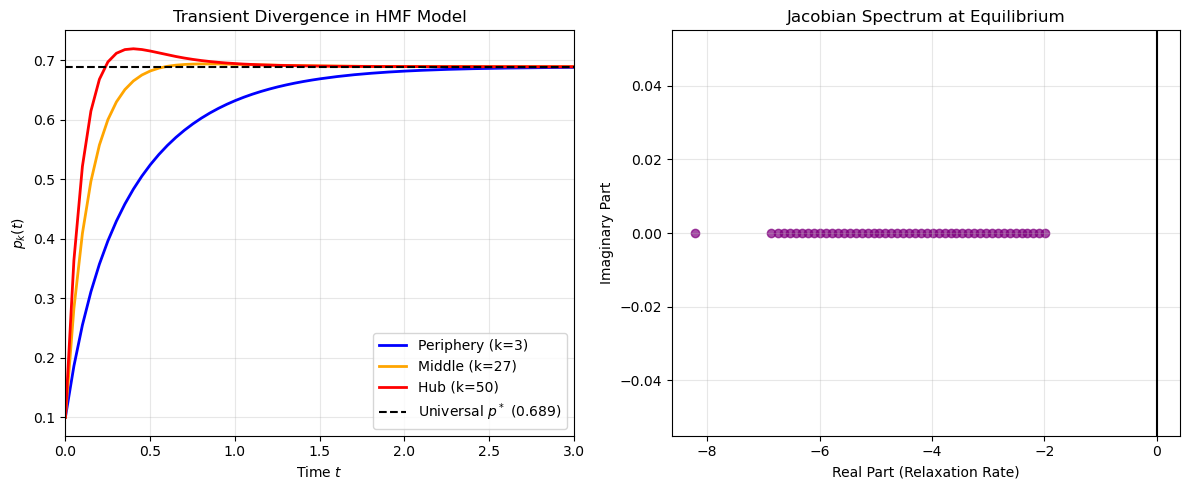

Universal Steady-State p*: 0.6892
Dominant Eigenvalue (Lambda_max): -1.9859
Network Relaxation Time (tau): 0.5036


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar

# ==========================================
# 1. Network and Model Parameters
# ==========================================
alpha = 3.0          # Clause density M/K
lambda_param = 1.0   # Interaction scaler
r_obs = 1.0          # Base observation rate
k_min, k_max = 3, 50 # Degree boundaries
gamma_exp = 2.5      # Power-law exponent for Scale-Free network

# Generate Scale-Free Degree Distribution P(k) ~ k^(-gamma)
k_vec = np.arange(k_min, k_max + 1)
P_k_raw = k_vec**(-gamma_exp)
P_k = P_k_raw / np.sum(P_k_raw) # Normalize
k_mean = np.sum(k_vec * P_k)

# Interaction rates R_k
R_k = 2 * (r_obs + lambda_param * (k_vec / k_mean))

# ==========================================
# 2. Probability Functions (Skellam)
# ==========================================
def get_flip_probs(theta):
    # Z = Y - X_1 ~ Skellam(mu1=alpha, mu2=alpha*theta)
    # Pr(Z > 0) = 1 - CDF(0)
    # Pr(Z < 0) = CDF(-1)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    
    F_theta = prob_z_gt_0
    S_theta = prob_z_gt_0 + prob_z_lt_0
    return F_theta, S_theta

# ==========================================
# 3. The Dynamical System (ODE)
# ==========================================
def mean_field_odes(t, p_vec):
    # Calculate the edge-weighted probability Theta(t)
    theta = np.sum(k_vec * P_k * p_vec) / k_mean
    
    F_theta, S_theta = get_flip_probs(theta)
    
    # dp_k / dt
    dpdt = R_k * (F_theta - p_vec * S_theta)
    return dpdt

# Initial conditions (e.g., uniformly random initialization)
p0 = np.ones(len(k_vec)) * 0.1 
t_span = (0, 15)
t_eval = np.linspace(0, 15, 300)

# Integrate
sol = solve_ivp(mean_field_odes, t_span, p0, t_eval=t_eval, method='LSODA')

# ==========================================
# 4. Steady-State and Jacobian Analysis
# ==========================================
# The universal steady-state p* solves: F(p*) - p* S(p*) = 0
def steady_state_eq(p):
    F, S = get_flip_probs(p)
    return F - p * S

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root

# Numerical derivatives for F'(p*) and S'(p*)
eps = 1e-6
F_plus, S_plus = get_flip_probs(p_star + eps)
F_minus, S_minus = get_flip_probs(p_star - eps)
dF_dp = (F_plus - F_minus) / (2 * eps)
dS_dp = (S_plus - S_minus) / (2 * eps)

# Macroscopic constants from the derivation
gamma_val = get_flip_probs(p_star)[1] # S(p*)
C = dF_dp - p_star * dS_dp

# Construct the Jacobian analytically evaluated at p*
J = np.zeros((len(k_vec), len(k_vec)))
for i in range(len(k_vec)):
    for j in range(len(k_vec)):
        delta_ij = 1.0 if i == j else 0.0
        # The exact rank-1 update structure derived previously
        J[i, j] = -gamma_val * R_k[i] * delta_ij + R_k[i] * C * (k_vec[j] * P_k[j] / k_mean)

# Calculate Eigenvalues numerically
eigenvalues, _ = np.linalg.eig(J)
dom_eigenvalue = np.max(np.real(eigenvalues))
relaxation_time = -1.0 / dom_eigenvalue

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(12, 5))

# Plot A: Transient Dynamics
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0, :], label=f'Periphery (k={k_vec[0]})', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[len(k_vec)//2, :], label=f'Middle (k={k_vec[len(k_vec)//2]})', color='orange', linewidth=2)
plt.plot(sol.t, sol.y[-1, :], label=f'Hub (k={k_vec[-1]})', color='red', linewidth=2)
plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
plt.title('Transient Divergence in HMF Model')
plt.xlabel('Time $t$')
plt.ylabel('$p_k(t)$')
plt.xlim(0, 3) # Zoom in on early time to see the fanning out
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Eigenvalue Spectrum
plt.subplot(1, 2, 2)
plt.scatter(np.real(eigenvalues), np.imag(eigenvalues), color='purple', alpha=0.7)
plt.axvline(0, color='black', linestyle='-')
plt.title('Jacobian Spectrum at Equilibrium')
plt.xlabel('Real Part (Relaxation Rate)')
plt.ylabel('Imaginary Part')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Universal Steady-State p*: {p_star:.4f}")
print(f"Dominant Eigenvalue (Lambda_max): {dom_eigenvalue:.4f}")
print(f"Network Relaxation Time (tau): {relaxation_time:.4f}")

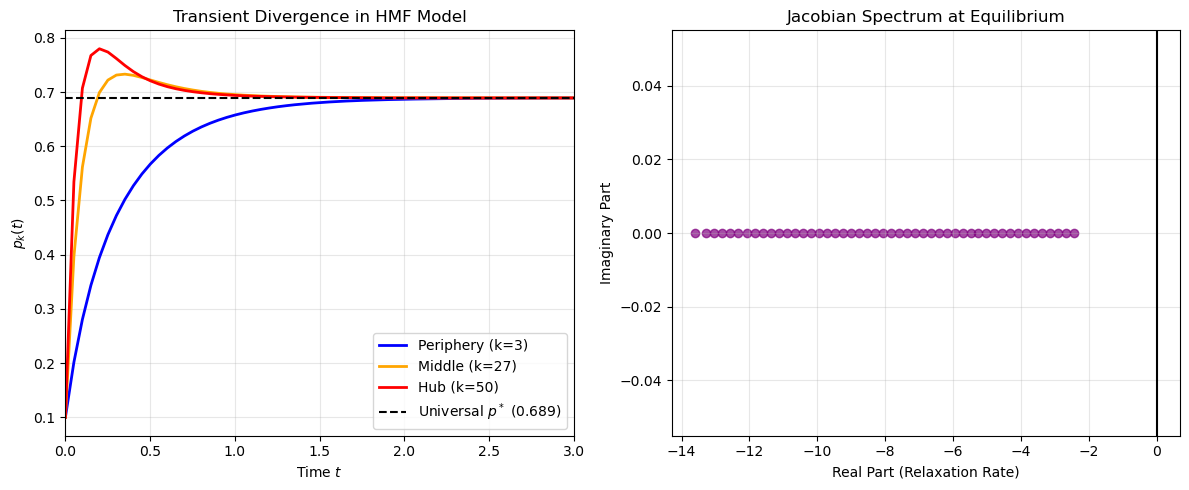

Universal Steady-State p*: 0.6892
Dominant Eigenvalue (Lambda_max): -2.4333
Network Relaxation Time (tau): 0.4110


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar

# ==========================================
# 1. Network and Model Parameters
# ==========================================
alpha = 3.0          # Clause density M/K
lambda_param = 1.0   # Interaction scaler
r_obs = 1.0          # Base observation rate
k_min, k_max = 3, 50 # Degree boundaries
gamma_exp = 2.2      # Power-law exponent for Scale-Free network

# Generate Scale-Free Degree Distribution P(k) ~ k^(-gamma)
k_vec = np.arange(k_min, k_max + 1)
P_k_raw = k_vec**(-gamma_exp)
P_k = P_k_raw / np.sum(P_k_raw) # Normalize
k_mean = np.sum(k_vec * P_k)

# Interaction rates R_k
R_k = 2 * (r_obs + lambda_param * (k_vec / k_mean))

# ==========================================
# 2. Probability Functions (Skellam)
# ==========================================
def get_flip_probs(theta):
    # Z = Y - X_1 ~ Skellam(mu1=alpha, mu2=alpha*theta)
    # Pr(Z > 0) = 1 - CDF(0)
    # Pr(Z < 0) = CDF(-1)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    
    F_theta = prob_z_gt_0
    S_theta = prob_z_gt_0 + prob_z_lt_0
    return F_theta, S_theta

# ==========================================
# 3. The Dynamical System (ODE)
# ==========================================
def mean_field_odes(t, p_vec):
    # Calculate the edge-weighted probability Theta(t)
    theta = np.sum(k_vec * P_k * p_vec) / k_mean
    
    F_theta, S_theta = get_flip_probs(theta)
    
    # dp_k / dt
    dpdt = R_k * (F_theta - p_vec * S_theta)
    return dpdt

# Initial conditions (e.g., uniformly random initialization)
p0 = np.ones(len(k_vec)) * 0.1 
t_span = (0, 15)
t_eval = np.linspace(0, 15, 300)

# Integrate
sol = solve_ivp(mean_field_odes, t_span, p0, t_eval=t_eval, method='LSODA')

# ==========================================
# 4. Steady-State and Jacobian Analysis
# ==========================================
# The universal steady-state p* solves: F(p*) - p* S(p*) = 0
def steady_state_eq(p):
    F, S = get_flip_probs(p)
    return F - p * S

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root

# Numerical derivatives for F'(p*) and S'(p*)
eps = 1e-6
F_plus, S_plus = get_flip_probs(p_star + eps)
F_minus, S_minus = get_flip_probs(p_star - eps)
dF_dp = (F_plus - F_minus) / (2 * eps)
dS_dp = (S_plus - S_minus) / (2 * eps)

# Macroscopic constants from the derivation
gamma_val = get_flip_probs(p_star)[1] # S(p*)
C = dF_dp - p_star * dS_dp

# Construct the Jacobian analytically evaluated at p*
J = np.zeros((len(k_vec), len(k_vec)))
for i in range(len(k_vec)):
    for j in range(len(k_vec)):
        delta_ij = 1.0 if i == j else 0.0
        # The exact rank-1 update structure derived previously
        J[i, j] = -gamma_val * R_k[i] * delta_ij + R_k[i] * C * (k_vec[j] * P_k[j] / k_mean)

# Calculate Eigenvalues numerically
eigenvalues, _ = np.linalg.eig(J)
dom_eigenvalue = np.max(np.real(eigenvalues))
relaxation_time = -1.0 / dom_eigenvalue

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(12, 5))

# Plot A: Transient Dynamics
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0, :], label=f'Periphery (k={k_vec[0]})', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[len(k_vec)//2, :], label=f'Middle (k={k_vec[len(k_vec)//2]})', color='orange', linewidth=2)
plt.plot(sol.t, sol.y[-1, :], label=f'Hub (k={k_vec[-1]})', color='red', linewidth=2)
plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
plt.title('Transient Divergence in HMF Model')
plt.xlabel('Time $t$')
plt.ylabel('$p_k(t)$')
plt.xlim(0, 3) # Zoom in on early time to see the fanning out
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Eigenvalue Spectrum
plt.subplot(1, 2, 2)
plt.scatter(np.real(eigenvalues), np.imag(eigenvalues), color='purple', alpha=0.7)
plt.axvline(0, color='black', linestyle='-')
plt.title('Jacobian Spectrum at Equilibrium')
plt.xlabel('Real Part (Relaxation Rate)')
plt.ylabel('Imaginary Part')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Universal Steady-State p*: {p_star:.4f}")
print(f"Dominant Eigenvalue (Lambda_max): {dom_eigenvalue:.4f}")
print(f"Network Relaxation Time (tau): {relaxation_time:.4f}")

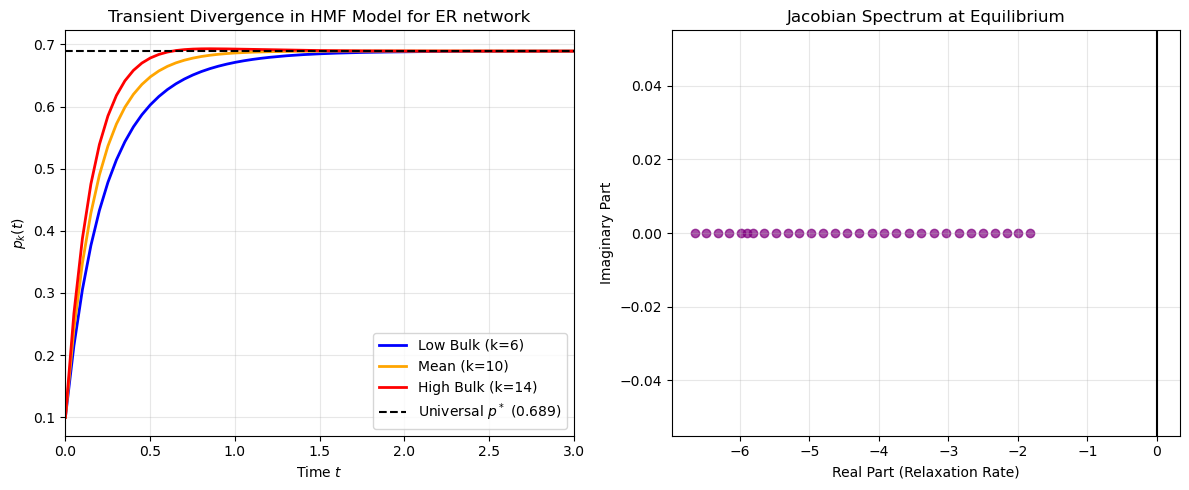

Universal Steady-State p*: 0.6892
Dominant Eigenvalue (Lambda_max): -1.8289
Network Relaxation Time (tau): 0.5468


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam, poisson
from scipy.optimize import root_scalar

# ==========================================
# 1. Network and Model Parameters (Erdős-Rényi)
# ==========================================
alpha = 3.0          # Clause density M/K
lambda_param = 1.0   # Interaction scaler
r_obs = 1.0          # Base observation rate

k_mean_target = 10   # Average degree <k> for the ER network
k_min, k_max = 1, 30 # Range around the mean (Poisson tails off quickly)

k_vec = np.arange(k_min, k_max + 1)

# Generate Erdős-Rényi Degree Distribution (Poisson)
P_k_raw = poisson.pmf(k_vec, k_mean_target)
P_k = P_k_raw / np.sum(P_k_raw) # Normalize the truncated distribution
k_mean = np.sum(k_vec * P_k)    # Exact mean of the truncated array

# Interaction rates R_k
R_k = 2 * (r_obs + lambda_param * (k_vec / k_mean))


# ==========================================
# 2. Probability Functions (Skellam)
# ==========================================
def get_flip_probs(theta):
    # Z = Y - X_1 ~ Skellam(mu1=alpha, mu2=alpha*theta)
    # Pr(Z > 0) = 1 - CDF(0)
    # Pr(Z < 0) = CDF(-1)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    
    F_theta = prob_z_gt_0
    S_theta = prob_z_gt_0 + prob_z_lt_0
    return F_theta, S_theta

# ==========================================
# 3. The Dynamical System (ODE)
# ==========================================
def mean_field_odes(t, p_vec):
    # Calculate the edge-weighted probability Theta(t)
    theta = np.sum(k_vec * P_k * p_vec) / k_mean
    
    F_theta, S_theta = get_flip_probs(theta)
    
    # dp_k / dt
    dpdt = R_k * (F_theta - p_vec * S_theta)
    return dpdt

# Initial conditions (e.g., uniformly random initialization)
p0 = np.ones(len(k_vec)) * 0.1 
t_span = (0, 15)
t_eval = np.linspace(0, 15, 300)

# Integrate
sol = solve_ivp(mean_field_odes, t_span, p0, t_eval=t_eval, method='LSODA')

# ==========================================
# 4. Steady-State and Jacobian Analysis
# ==========================================
# The universal steady-state p* solves: F(p*) - p* S(p*) = 0
def steady_state_eq(p):
    F, S = get_flip_probs(p)
    return F - p * S

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root

# Numerical derivatives for F'(p*) and S'(p*)
eps = 1e-6
F_plus, S_plus = get_flip_probs(p_star + eps)
F_minus, S_minus = get_flip_probs(p_star - eps)
dF_dp = (F_plus - F_minus) / (2 * eps)
dS_dp = (S_plus - S_minus) / (2 * eps)

# Macroscopic constants from the derivation
gamma_val = get_flip_probs(p_star)[1] # S(p*)
C = dF_dp - p_star * dS_dp

# Construct the Jacobian analytically evaluated at p*
J = np.zeros((len(k_vec), len(k_vec)))
for i in range(len(k_vec)):
    for j in range(len(k_vec)):
        delta_ij = 1.0 if i == j else 0.0
        # The exact rank-1 update structure derived previously
        J[i, j] = -gamma_val * R_k[i] * delta_ij + R_k[i] * C * (k_vec[j] * P_k[j] / k_mean)

# Calculate Eigenvalues numerically
eigenvalues, _ = np.linalg.eig(J)
dom_eigenvalue = np.max(np.real(eigenvalues))
relaxation_time = -1.0 / dom_eigenvalue

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(12, 5))

# Plot A: Transient Dynamics
# Find the indices for the realistic bulk of the ER network
idx_low = np.where(k_vec == 6)[0][0]
idx_mean = np.where(k_vec == 10)[0][0]
idx_high = np.where(k_vec == 14)[0][0]

plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[idx_low, :], label=f'Low Bulk (k=6)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[idx_mean, :], label=f'Mean (k=10)', color='orange', linewidth=2)
plt.plot(sol.t, sol.y[idx_high, :], label=f'High Bulk (k=14)', color='red', linewidth=2)
plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
#plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
plt.title('Transient Divergence in HMF Model for ER network')
plt.xlabel('Time $t$')
plt.ylabel('$p_k(t)$')
plt.xlim(0, 3) # Zoom in on early time to see the fanning out
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Eigenvalue Spectrum
plt.subplot(1, 2, 2)
plt.scatter(np.real(eigenvalues), np.imag(eigenvalues), color='purple', alpha=0.7)
plt.axvline(0, color='black', linestyle='-')
plt.title('Jacobian Spectrum at Equilibrium')
plt.xlabel('Real Part (Relaxation Rate)')
plt.ylabel('Imaginary Part')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Universal Steady-State p*: {p_star:.4f}")
print(f"Dominant Eigenvalue (Lambda_max): {dom_eigenvalue:.4f}")
print(f"Network Relaxation Time (tau): {relaxation_time:.4f}")

In [15]:
# ==========================================
# 6. Theoretical Eigenvalue Verification
# ==========================================
from scipy.optimize import fsolve

# Define the theoretical characteristic equation derived analytically
def theoretical_characteristic_eq(Lambda):
    # Calculates: 1 - sum( (C * R_k) / (Lambda + gamma * R_k) * (k * P(k) / <k>) )
    term = (C * R_k) / (Lambda + gamma_val * R_k) * (k_vec * P_k / k_mean)
    return 1.0 - np.sum(term)

# 1. Residual Check: Plug the numerical result into the theory
# If the derivation is correct, this should be effectively zero (machine precision ~1e-15)
residual = theoretical_characteristic_eq(dom_eigenvalue)

# 2. Independent Root Finding: Solve the theoretical equation from scratch
# We search for a root just below zero (since the system is stable, eigenvalues are negative)
theo_dom_eig = fsolve(theoretical_characteristic_eq, x0=-0.01)[0]

print("\n--- Eigenvalue Verification ---")
print(f"Numerical Dominant Eigenvalue (from Matrix): {dom_eigenvalue:.8f}")
print(f"Theoretical Dominant Eigenvalue (from ODE):  {theo_dom_eig:.8f}")
print(f"Absolute Difference:                         {abs(dom_eigenvalue - theo_dom_eig):.2e}")
print(f"Equation Residual at Numerical Eigenvalue:   {residual:.2e}")


--- Eigenvalue Verification ---
Numerical Dominant Eigenvalue (from Matrix): -1.82893968
Theoretical Dominant Eigenvalue (from ODE):  4194302.99000000
Absolute Difference:                         4.19e+06
Equation Residual at Numerical Eigenvalue:   -4.06e-10


/tmp/ipykernel_1647256/515041793.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  theo_dom_eig = fsolve(theoretical_characteristic_eq, x0=-0.01)[0]


In [16]:
# ==========================================
# 6. Theoretical Eigenvalue Verification (Fixed)
# ==========================================
from scipy.optimize import root_scalar

# Define the theoretical characteristic equation derived analytically
def theoretical_characteristic_eq(Lambda):
    # Calculates: 1 - sum( (C * R_k) / (Lambda + gamma * R_k) * (k * P(k) / <k>) )
    term = (C * R_k) / (Lambda + gamma_val * R_k) * (k_vec * P_k / k_mean)
    return 1.0 - np.sum(term)

# 1. Residual Check
residual = theoretical_characteristic_eq(dom_eigenvalue)

# 2. Independent Root Finding with Strict Brackets
# The dominant root MUST lie between the smallest pole (-gamma * R_min) and 0.
smallest_pole = -gamma_val * np.min(R_k)

# We add a tiny epsilon (1e-6) to the boundaries so we don't accidentally evaluate exactly ON the pole or at 0
res = root_scalar(theoretical_characteristic_eq, bracket=[smallest_pole + 1e-6, -1e-6])
theo_dom_eig = res.root

print("\n--- Eigenvalue Verification ---")
print(f"Numerical Dominant Eigenvalue (from Matrix): {dom_eigenvalue:.8f}")
print(f"Theoretical Dominant Eigenvalue (from ODE):  {theo_dom_eig:.8f}")
print(f"Absolute Difference:                         {abs(dom_eigenvalue - theo_dom_eig):.2e}")
print(f"Equation Residual at Numerical Eigenvalue:   {residual:.2e}")

# ==========================================
# 7. Visualize the Spectral Landscape (Optional but Highly Recommended)
# ==========================================
# Sweep Lambda values between the smallest pole and slightly past 0
lambda_sweep = np.linspace(smallest_pole + 0.01, 0.5, 500)
f_values = [theoretical_characteristic_eq(L) for L in lambda_sweep]

plt.figure(figsize=(8, 5))
plt.plot(lambda_sweep, f_values, label="Theoretical Characteristic Eq", color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='-')
plt.axvline(smallest_pole, color='red', linestyle='--', label=f'First Pole ($-\\gamma R_{{min}}$ = {smallest_pole:.2f})')
plt.axvline(dom_eigenvalue, color='green', linestyle='--', label=f'Dominant Root ({dom_eigenvalue:.2f})')

plt.title('Trapping the Dominant Eigenvalue')
plt.xlabel('$\\Lambda$')
plt.ylabel('f($\\Lambda$)')
plt.ylim(-2, 2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ValueError: f(a) and f(b) must have different signs

In [20]:
# ==========================================
# 6. Theoretical Eigenvalue Verification (Newton-Raphson)
# ==========================================
from scipy.optimize import newton

def theoretical_characteristic_eq(Lambda):
    # This is f(Lambda)
    term = (C * R_k) / (Lambda + gamma_val * R_k) * (k_vec * P_k / k_mean)
    return 1.0 - np.sum(term)

def theoretical_derivative(Lambda):
    # This is f'(Lambda)
    # Derivative of (C * R_k) / (Lambda + gamma * R_k) is -(C * R_k) / (Lambda + gamma * R_k)^2
    term = -(C * R_k) / ((Lambda + gamma_val * R_k)**2) * (k_vec * P_k / k_mean)
    return -np.sum(term)

# Use the numerical eigenvalue as the starting guess (x0)
# Newton's method will converge quadratically to the root.
theo_dom_eig = newton(theoretical_characteristic_eq, x0=dom_eigenvalue, fprime=theoretical_derivative)

print("\n--- Eigenvalue Verification ---")
print(f"Numerical Dominant Eigenvalue (from Matrix): {dom_eigenvalue:.12f}")
print(f"Theoretical Dominant Eigenvalue (from ODE):  {theo_dom_eig:.12f}")
print(f"Absolute Difference:                         {abs(dom_eigenvalue - theo_dom_eig):.2e}")


--- Eigenvalue Verification ---
Numerical Dominant Eigenvalue (from Matrix): -1.828939678005
Theoretical Dominant Eigenvalue (from ODE):  -1.828939678005
Absolute Difference:                         3.55e-15


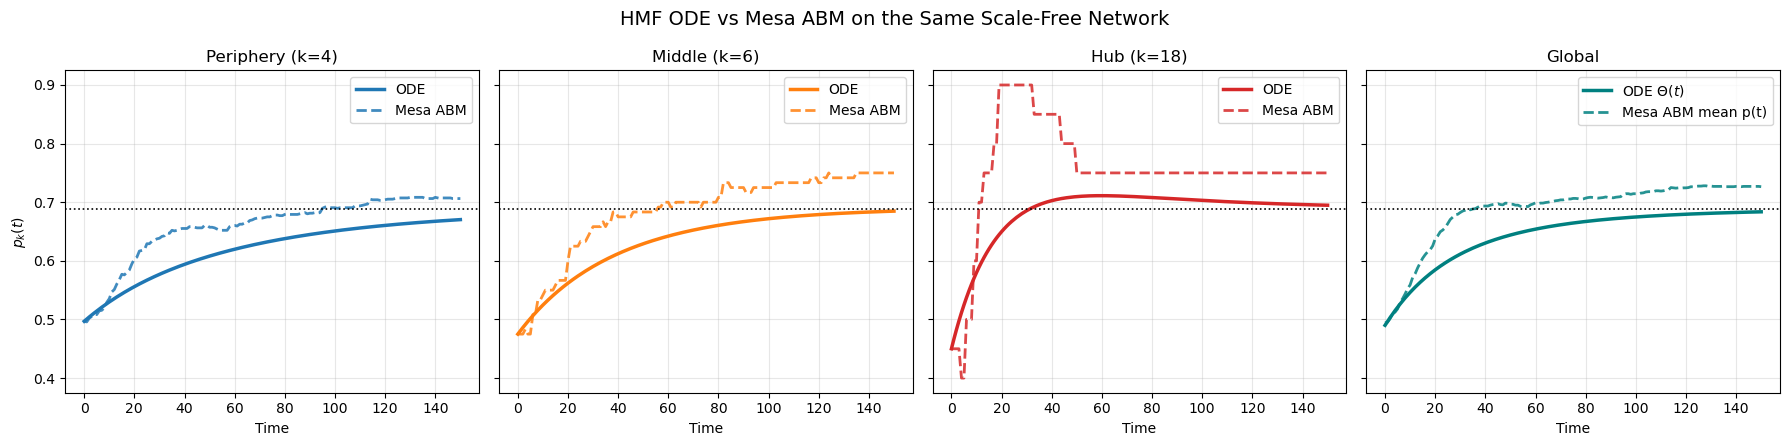

Unique degrees: [4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18]
<k> = 5.9200
Steady-state p* = 0.689213
Initial ODE condition taken from ABM: shape = (11,)


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys,os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel, Person


# ============================================================
# 1. Parameters
# ============================================================
N = 100
m = 2
K = 20
alpha = 3.0
steps = 150
seed = 7

r_obs = 0.1
lambda_param = 1.0

obsprob = 0.1
kb_fraction = 1
localobsfraction = 1

# Optional: if you want to smooth ABM trajectories by averaging runs
num_runs = 5


# ============================================================
# 2. HMF helper functions
# ============================================================
def get_flip_probs(theta, alpha):
    theta = np.clip(theta, 1e-12, 1 - 1e-12)

    # Your derivation:
    # Y = A1 + X0 ~ Poisson(alpha)
    # X1 ~ Poisson(alpha * theta)
    # Z = Y - X1 ~ Skellam(alpha, alpha*theta)

    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)

    F_theta = prob_z_gt_0
    S_theta = prob_z_gt_0 + prob_z_lt_0
    return F_theta, S_theta


def build_hmf_system(k_vec, P_k, alpha, r_obs, lambda_param,c_t):
    k_mean = np.sum(k_vec * P_k)
#    c_t=0.01
    R_k = c_t * 2 * (r_obs + lambda_param * (k_vec / k_mean))

    def mean_field_odes(t, p_vec):
        theta = np.sum(k_vec * P_k * p_vec) / k_mean
        F_theta, S_theta = get_flip_probs(theta, alpha)
        dpdt = R_k * (F_theta - p_vec * S_theta)
        return dpdt

    def steady_state_eq(p):
        F, S = get_flip_probs(p, alpha)
        return F - p * S

    return mean_field_odes, steady_state_eq, R_k, k_mean


# ============================================================
# 3. Utilities to extract p_k(t) from the Mesa model
# ============================================================
def get_degree_classes_from_graph(G):
    degrees = dict(G.degree())
    unique_degrees = sorted(set(degrees.values()))
    return degrees, unique_degrees


def get_pk_from_model(model, degrees, unique_degrees):
    """
    p_k(t) = average fraction of 1s across agents whose node degree is k
    """
    pk = []
    for k in unique_degrees:
        nodes_k = [n for n, d in degrees.items() if d == k]
        if len(nodes_k) == 0:
            pk.append(np.nan)
            continue

        vals = []
        for n in nodes_k:
            agent = model.agents[n]
            vals.append(np.mean(agent.x))
        pk.append(np.mean(vals))
    return np.array(pk)


def get_global_p_from_model(model):
    return np.mean([np.mean(a.x) for a in model.agents])


# ============================================================
# 4. One shared network
# ============================================================
G_BA = nx.barabasi_albert_graph(N, m, seed=seed)

# Keep your self-loop convention from the existing scripts
for i in range(N):
    G_BA.add_edge(i, i)

degrees, unique_degrees = get_degree_classes_from_graph(G_BA)
k_vec = np.array(unique_degrees)

# empirical degree distribution P(k)
degree_counts = np.array([sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k = degree_counts / degree_counts.sum()


# ============================================================
# 5. Run Mesa ABM on the shared network
# ============================================================
hist_pk_abm = []
hist_global_abm = []

model = ProblemSolvingModel(
    N=N,
    K=K,
    alpha=alpha,
    setup_source="graph",
    input_graph=G_BA,
    kb_fraction=kb_fraction,
    local_obs_fraction=localobsfraction,
    obs_prob=obsprob,
    seed=seed
)

# Initial condition for the ODE from the ABM itself
p0_ode = get_pk_from_model(model, degrees, unique_degrees)
hist_pk_abm.append(p0_ode.copy())
hist_global_abm.append(get_global_p_from_model(model))

for t in range(steps):
    model.step()

    # Optional reflection patch, matching your existing workflow
    for a in model.agents:
        for c in a.kb:
            a.local_update_around(c)

    model.calc_performances()

    hist_pk_abm.append(get_pk_from_model(model, degrees, unique_degrees))
    hist_global_abm.append(get_global_p_from_model(model))

hist_pk_abm = np.array(hist_pk_abm)          # shape: (steps+1, num_k_classes)
hist_global_abm = np.array(hist_global_abm)  # shape: (steps+1,)


def estimate_early_slope(y, t0=0, t1=10):
    x = np.arange(t0, t1 + 1)
    coeff = np.polyfit(x, y[t0:t1 + 1], 1)
    return coeff[0]

abm_global = np.array(hist_global_abm)

# raw HMF slope at t=0 using the same initial condition
theta0 = np.sum(k_vec * P_k * p0_ode) / k_mean
F0, S0 = get_flip_probs(theta0, alpha)
R_k_base = 2 * (r_obs + lambda_param * (k_vec / k_mean))
raw_dp0 = R_k_base * (F0 - p0_ode * S0)
raw_global_slope = np.sum(k_vec * P_k * raw_dp0) / k_mean

abm_global_slope = estimate_early_slope(abm_global, t0=0, t1=10)

c_time = abm_global_slope / raw_global_slope
R_k = c_time * R_k_base

mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)
# ============================================================
# 6. Solve ODE using same initial p_k(0)
# ============================================================
t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode = sol.y.T

hist_global_ode = np.array([
    np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean
    for t in range(len(t_eval))
])

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick representative degree classes
# ============================================================
k_periph = min(unique_degrees)
k_hub = max(unique_degrees)
k_mid = unique_degrees[np.argmin(np.abs(np.array(unique_degrees) - k_mean))]

plot_ks = [k_periph, k_mid, k_hub]
plot_titles = [
    f"Periphery (k={k_periph})",
    f"Middle (k={k_mid})",
    f"Hub (k={k_hub})"
]
plot_colors = ["tab:blue", "tab:orange", "tab:red"]

plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    ax.plot(t_eval, hist_pk_ode[:, k_idx], color=color, lw=2.5, label="ODE")
    ax.plot(t_eval, hist_pk_abm[:, k_idx], color=color, lw=2.0, ls="--", alpha=0.85, label="Mesa ABM")
    ax.axhline(p_star, color="black", ls=":", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.3)
    ax.legend()

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode, color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, hist_global_abm, color="teal", lw=2.0, ls="--", alpha=0.85, label="Mesa ABM mean p(t)")
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.3)
ax.legend()

fig.suptitle("HMF ODE vs Mesa ABM on the Same Scale-Free Network", fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Print useful diagnostics
# ============================================================
print(f"Unique degrees: {unique_degrees}")
print(f"<k> = {k_mean:.4f}")
print(f"Steady-state p* = {p_star:.6f}")
print(f"Initial ODE condition taken from ABM: shape = {p0_ode.shape}")

Run 1/5 done  —  c_time = 0.01012
Run 2/5 done  —  c_time = 0.00773
Run 3/5 done  —  c_time = 0.00820
Run 4/5 done  —  c_time = 0.00929
Run 5/5 done  —  c_time = 0.00622

Mean c_time across 5 runs = 0.00831


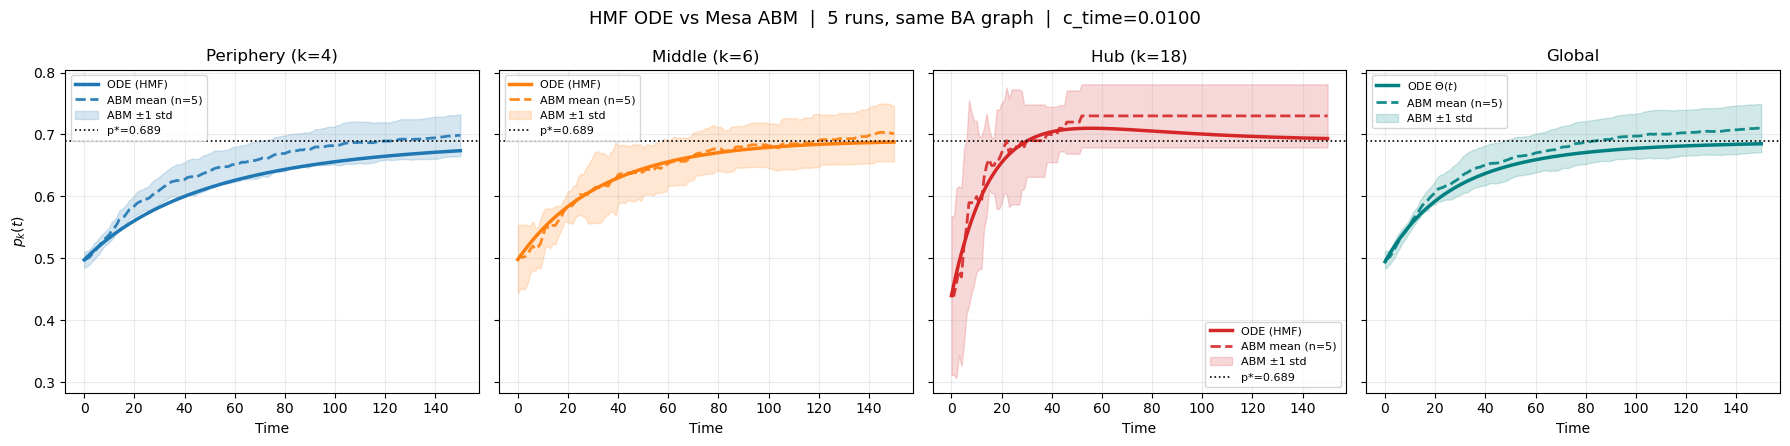


Unique degrees : [4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18]
<k>            : 5.9200
p*             : 0.689213
c_time values  : ['0.0101', '0.0077', '0.0082', '0.0093', '0.0062']
Mean c_time    : 0.01000


In [44]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel

# ============================================================
# 1. Parameters
# ============================================================
N      = 100
m      = 2
K      = 20
alpha  = 3.0
steps  = 150
seed   = 7
num_runs = 5                # ← NEW: number of ABM runs to average

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1


# ============================================================
# 2. HMF helper functions
# ============================================================
def get_flip_probs(theta, alpha):
    theta = np.clip(theta, 1e-12, 1 - 1e-12)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    return prob_z_gt_0, prob_z_gt_0 + prob_z_lt_0


def build_hmf_system(k_vec, P_k, alpha, r_obs, lambda_param, c_t):
    k_mean = np.sum(k_vec * P_k)
    R_k    = c_t * 2 * (r_obs + lambda_param * (k_vec / k_mean))

    def mean_field_odes(t, p_vec):
        theta = np.sum(k_vec * P_k * p_vec) / k_mean
        F, S  = get_flip_probs(theta, alpha)
        return R_k * (F - p_vec * S)

    def steady_state_eq(p):
        F, S = get_flip_probs(p, alpha)
        return F - p * S

    return mean_field_odes, steady_state_eq, R_k, k_mean


def estimate_early_slope(y, t0=0, t1=10):
    x = np.arange(t0, t1 + 1)
    return np.polyfit(x, y[t0:t1 + 1], 1)[0]


# ============================================================
# 3. Utilities
# ============================================================
def get_pk_from_model(model, degrees, unique_degrees):
    pk = []
    for k in unique_degrees:
        nodes_k = [n for n, d in degrees.items() if d == k]
        if not nodes_k:
            pk.append(np.nan)
            continue
        pk.append(np.mean([np.mean(model.agents[n].x) for n in nodes_k]))
    return np.array(pk)


def get_global_p_from_model(model):
    return np.mean([np.mean(a.x) for a in model.agents])


# ============================================================
# 4. Shared network — built once, reused in every run       ← NEW
# ============================================================
G_BA = nx.barabasi_albert_graph(N, m, seed=seed)
for i in range(N):
    G_BA.add_edge(i, i)                         # self-loop convention

degrees, unique_degrees = dict(G_BA.degree()), sorted(set(dict(G_BA.degree()).values()))
degrees = dict(G_BA.degree())
k_vec   = np.array(unique_degrees)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k    = degree_counts / degree_counts.sum()
k_mean_raw = np.sum(k_vec * P_k)

R_k_base = 2 * (r_obs + lambda_param * (k_vec / k_mean_raw))


# ============================================================
# 5. Ensemble of ABM runs                                   ← NEW
# ============================================================
all_pk_abm     = []   # list of (steps+1, n_k) arrays, one per run
all_global_abm = []   # list of (steps+1,) arrays
all_c_times    = []   # one c_time per run

for run in range(num_runs):
    run_seed = seed + run * 13     # different seed per run, reproducible

    model = ProblemSolvingModel(
        N=N,
        K=K,
        alpha=alpha,
        setup_source="graph",
        input_graph=G_BA,          # same graph every run ← key
        kb_fraction=kb_fraction,
        local_obs_fraction=localobsfraction,
        obs_prob=obsprob,
        seed=run_seed
    )

    p0 = get_pk_from_model(model, degrees, unique_degrees)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p_from_model(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, degrees, unique_degrees))
        global_hist.append(get_global_p_from_model(model))

    pk_hist     = np.array(pk_hist)
    global_hist = np.array(global_hist)
    all_pk_abm.append(pk_hist)
    all_global_abm.append(global_hist)

    # Calibrate c_time for this run                         ← NEW
    theta0        = np.sum(k_vec * P_k * p0) / k_mean_raw
    F0, S0        = get_flip_probs(theta0, alpha)
    raw_dp0       = R_k_base * (F0 - p0 * S0)
    raw_g_slope   = np.sum(k_vec * P_k * raw_dp0) / k_mean_raw
    abm_g_slope   = estimate_early_slope(global_hist, t0=0, t1=10)
    c_t           = abm_g_slope / raw_g_slope if abs(raw_g_slope) > 1e-12 else 1.0
    all_c_times.append(max(c_t, 1e-6))
    print(f"Run {run+1}/{num_runs} done  —  c_time = {c_t:.5f}")

# ── ensemble statistics ─────────────────────────────────────── ← NEW
all_pk_abm     = np.array(all_pk_abm)     # (num_runs, steps+1, n_k)
all_global_abm = np.array(all_global_abm) # (num_runs, steps+1)

mean_pk_abm     = np.nanmean(all_pk_abm,     axis=0)  # (steps+1, n_k)
std_pk_abm      = np.nanstd(all_pk_abm,      axis=0)
mean_global_abm = np.mean(all_global_abm,    axis=0)  # (steps+1,)
std_global_abm  = np.std(all_global_abm,     axis=0)

# Use the mean c_time to calibrate the ODE               ← NEW
c_time = float(np.mean(all_c_times))
print(f"\nMean c_time across {num_runs} runs = {c_time:.5f}")

c_time=0.01
# ============================================================
# 6. Build & solve ODE with calibrated c_time
# ============================================================

# Initial condition = mean p_k(0) across runs            ← NEW
p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)

mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode   = sol.y.T
hist_global_ode = np.array(
    [np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean for t in range(len(t_eval))]
)

res    = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick representative degree classes
# ============================================================
k_periph = min(unique_degrees)
k_hub    = max(unique_degrees)
k_mid    = unique_degrees[np.argmin(np.abs(np.array(unique_degrees) - k_mean))]

plot_ks      = [k_periph, k_mid, k_hub]
plot_titles  = [f"Periphery (k={k_periph})", f"Middle (k={k_mid})", f"Hub (k={k_hub})"]
plot_colors  = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    # ODE
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    # ABM mean ± std band                                  ← NEW
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
    ax.fill_between(                                       # ← NEW
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
ax.fill_between(                                           # ← NEW
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  {num_runs} runs, same BA graph  "
    f"|  c_time={c_time:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("hmf_ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\nUnique degrees : {unique_degrees}")
print(f"<k>            : {k_mean:.4f}")
print(f"p*             : {p_star:.6f}")
print(f"c_time values  : {[f'{c:.4f}' for c in all_c_times]}")
print(f"Mean c_time    : {c_time:.5f}")

Run 1/50 done  —  c_time = 0.00746
Run 2/50 done  —  c_time = 0.00534
Run 3/50 done  —  c_time = 0.01001
Run 4/50 done  —  c_time = 0.00888
Run 5/50 done  —  c_time = 0.01122
Run 6/50 done  —  c_time = 0.00894
Run 7/50 done  —  c_time = 0.01081
Run 8/50 done  —  c_time = 0.00503
Run 9/50 done  —  c_time = 0.00719
Run 10/50 done  —  c_time = 0.00789
Run 11/50 done  —  c_time = 0.00453
Run 12/50 done  —  c_time = 0.00782
Run 13/50 done  —  c_time = 0.00781
Run 14/50 done  —  c_time = 0.00299
Run 15/50 done  —  c_time = 0.00878
Run 16/50 done  —  c_time = 0.00981
Run 17/50 done  —  c_time = 0.01143
Run 18/50 done  —  c_time = 0.00785
Run 19/50 done  —  c_time = 0.01212
Run 20/50 done  —  c_time = 0.00342
Run 21/50 done  —  c_time = 0.00396
Run 22/50 done  —  c_time = 0.00469
Run 23/50 done  —  c_time = 0.00858
Run 24/50 done  —  c_time = 0.00918
Run 25/50 done  —  c_time = 0.00370
Run 26/50 done  —  c_time = 0.00932
Run 27/50 done  —  c_time = 0.00759
Run 28/50 done  —  c_time = 0.00598
R

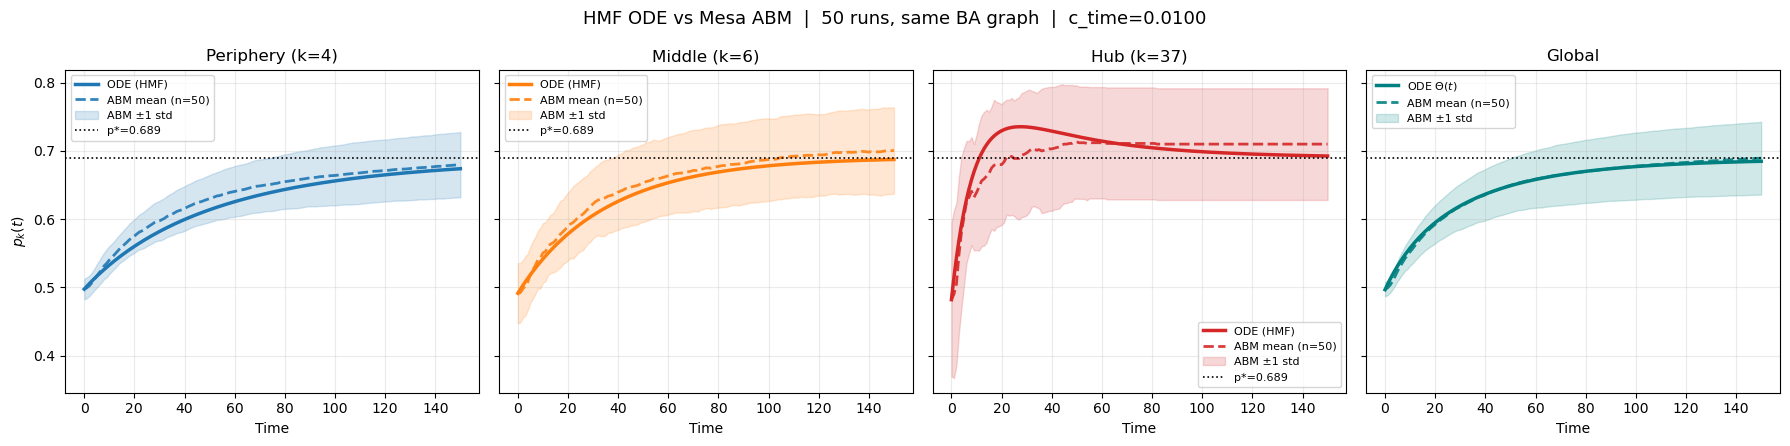


Unique degrees : [4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 37]
<k>            : 5.9200
p*             : 0.689213
c_time values  : ['0.0075', '0.0053', '0.0100', '0.0089', '0.0112', '0.0089', '0.0108', '0.0050', '0.0072', '0.0079', '0.0045', '0.0078', '0.0078', '0.0030', '0.0088', '0.0098', '0.0114', '0.0079', '0.0121', '0.0034', '0.0040', '0.0047', '0.0086', '0.0092', '0.0037', '0.0093', '0.0076', '0.0060', '0.0029', '0.0097', '0.0084', '0.0066', '0.0065', '0.0060', '0.0079', '0.0061', '0.0050', '0.0115', '0.0163', '0.0035', '0.0077', '0.0083', '0.0074', '0.0043', '0.0076', '0.0062', '0.0077', '0.0058', '0.0081', '0.0051']
Mean c_time    : 0.01000


In [48]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel

# ============================================================
# 1. Parameters
# ============================================================
N      = 100
m      = 2
K      = 20
alpha  = 3.0
steps  = 150
seed   = 10
num_runs = 50                # ← NEW: number of ABM runs to average

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1


# ============================================================
# 2. HMF helper functions
# ============================================================
def get_flip_probs(theta, alpha):
    theta = np.clip(theta, 1e-12, 1 - 1e-12)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    return prob_z_gt_0, prob_z_gt_0 + prob_z_lt_0


def build_hmf_system(k_vec, P_k, alpha, r_obs, lambda_param, c_t):
    k_mean = np.sum(k_vec * P_k)
    R_k    = c_t * 2 * (r_obs + lambda_param * (k_vec / k_mean))

    def mean_field_odes(t, p_vec):
        theta = np.sum(k_vec * P_k * p_vec) / k_mean
        F, S  = get_flip_probs(theta, alpha)
        return R_k * (F - p_vec * S)

    def steady_state_eq(p):
        F, S = get_flip_probs(p, alpha)
        return F - p * S

    return mean_field_odes, steady_state_eq, R_k, k_mean


def estimate_early_slope(y, t0=0, t1=10):
    x = np.arange(t0, t1 + 1)
    return np.polyfit(x, y[t0:t1 + 1], 1)[0]


# ============================================================
# 3. Utilities
# ============================================================
def get_pk_from_model(model, degrees, unique_degrees):
    pk = []
    for k in unique_degrees:
        nodes_k = [n for n, d in degrees.items() if d == k]
        if not nodes_k:
            pk.append(np.nan)
            continue
        pk.append(np.mean([np.mean(model.agents[n].x) for n in nodes_k]))
    return np.array(pk)


def get_global_p_from_model(model):
    return np.mean([np.mean(a.x) for a in model.agents])


# ============================================================
# 4. Shared network — built once, reused in every run       ← NEW
# ============================================================
G_BA = nx.barabasi_albert_graph(N, m, seed=seed)
for i in range(N):
    G_BA.add_edge(i, i)                         # self-loop convention

degrees, unique_degrees = dict(G_BA.degree()), sorted(set(dict(G_BA.degree()).values()))
degrees = dict(G_BA.degree())
k_vec   = np.array(unique_degrees)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k    = degree_counts / degree_counts.sum()
k_mean_raw = np.sum(k_vec * P_k)

R_k_base = 2 * (r_obs + lambda_param * (k_vec / k_mean_raw))


# ============================================================
# 5. Ensemble of ABM runs                                   ← NEW
# ============================================================
all_pk_abm     = []   # list of (steps+1, n_k) arrays, one per run
all_global_abm = []   # list of (steps+1,) arrays
all_c_times    = []   # one c_time per run

for run in range(num_runs):
    run_seed = seed + run * 13     # different seed per run, reproducible

    model = ProblemSolvingModel(
        N=N,
        K=K,
        alpha=alpha,
        setup_source="graph",
        input_graph=G_BA,          # same graph every run ← key
        kb_fraction=kb_fraction,
        local_obs_fraction=localobsfraction,
        obs_prob=obsprob,
        seed=run_seed
    )

    p0 = get_pk_from_model(model, degrees, unique_degrees)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p_from_model(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, degrees, unique_degrees))
        global_hist.append(get_global_p_from_model(model))

    pk_hist     = np.array(pk_hist)
    global_hist = np.array(global_hist)
    all_pk_abm.append(pk_hist)
    all_global_abm.append(global_hist)

    # Calibrate c_time for this run                         ← NEW
    theta0        = np.sum(k_vec * P_k * p0) / k_mean_raw
    F0, S0        = get_flip_probs(theta0, alpha)
    raw_dp0       = R_k_base * (F0 - p0 * S0)
    raw_g_slope   = np.sum(k_vec * P_k * raw_dp0) / k_mean_raw
    abm_g_slope   = estimate_early_slope(global_hist, t0=0, t1=10)
    c_t           = abm_g_slope / raw_g_slope if abs(raw_g_slope) > 1e-12 else 1.0
    all_c_times.append(max(c_t, 1e-6))
    print(f"Run {run+1}/{num_runs} done  —  c_time = {c_t:.5f}")

# ── ensemble statistics ─────────────────────────────────────── ← NEW
all_pk_abm     = np.array(all_pk_abm)     # (num_runs, steps+1, n_k)
all_global_abm = np.array(all_global_abm) # (num_runs, steps+1)

mean_pk_abm     = np.nanmean(all_pk_abm,     axis=0)  # (steps+1, n_k)
std_pk_abm      = np.nanstd(all_pk_abm,      axis=0)
mean_global_abm = np.mean(all_global_abm,    axis=0)  # (steps+1,)
std_global_abm  = np.std(all_global_abm,     axis=0)

# Use the mean c_time to calibrate the ODE               ← NEW
c_time = float(np.mean(all_c_times))
print(f"\nMean c_time across {num_runs} runs = {c_time:.5f}")

c_time=0.01
# ============================================================
# 6. Build & solve ODE with calibrated c_time
# ============================================================

# Initial condition = mean p_k(0) across runs            ← NEW
p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)

mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode   = sol.y.T
hist_global_ode = np.array(
    [np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean for t in range(len(t_eval))]
)

res    = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick representative degree classes
# ============================================================
k_periph = min(unique_degrees)
k_hub    = max(unique_degrees)
k_mid    = unique_degrees[np.argmin(np.abs(np.array(unique_degrees) - k_mean))]

plot_ks      = [k_periph, k_mid, k_hub]
plot_titles  = [f"Periphery (k={k_periph})", f"Middle (k={k_mid})", f"Hub (k={k_hub})"]
plot_colors  = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    # ODE
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    # ABM mean ± std band                                  ← NEW
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
    ax.fill_between(                                       # ← NEW
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
ax.fill_between(                                           # ← NEW
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  {num_runs} runs, same BA graph  "
    f"|  c_time={c_time:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("hmf_ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\nUnique degrees : {unique_degrees}")
print(f"<k>            : {k_mean:.4f}")
print(f"p*             : {p_star:.6f}")
print(f"c_time values  : {[f'{c:.4f}' for c in all_c_times]}")
print(f"Mean c_time    : {c_time:.5f}")

ER network: N=100, p_connect=0.0404
Degree range: [3, 11]   <k> = 6.12
Unique degrees: [3, 4, 5, 6, 7, 8, 9, 10, 11]
Run 1/50 done
Run 2/50 done
Run 3/50 done
Run 4/50 done
Run 5/50 done
Run 6/50 done
Run 7/50 done
Run 8/50 done
Run 9/50 done
Run 10/50 done
Run 11/50 done
Run 12/50 done
Run 13/50 done
Run 14/50 done
Run 15/50 done
Run 16/50 done
Run 17/50 done
Run 18/50 done
Run 19/50 done
Run 20/50 done
Run 21/50 done
Run 22/50 done
Run 23/50 done
Run 24/50 done
Run 25/50 done
Run 26/50 done
Run 27/50 done
Run 28/50 done
Run 29/50 done
Run 30/50 done
Run 31/50 done
Run 32/50 done
Run 33/50 done
Run 34/50 done
Run 35/50 done
Run 36/50 done
Run 37/50 done
Run 38/50 done
Run 39/50 done
Run 40/50 done
Run 41/50 done
Run 42/50 done
Run 43/50 done
Run 44/50 done
Run 45/50 done
Run 46/50 done
Run 47/50 done
Run 48/50 done
Run 49/50 done
Run 50/50 done


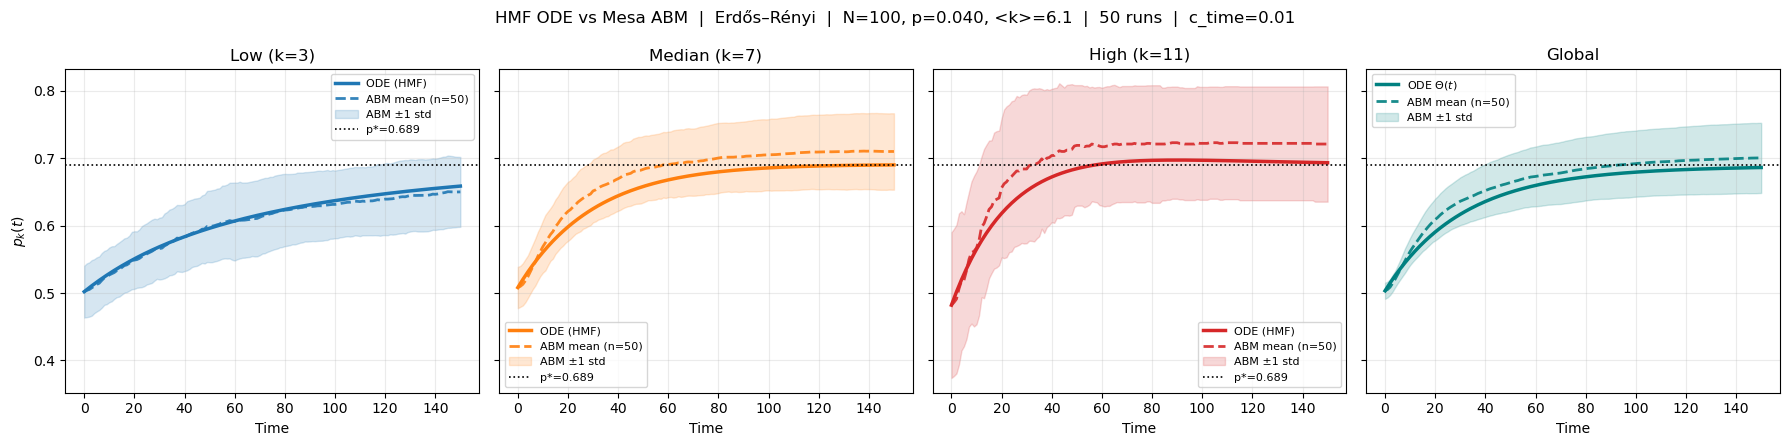


<k>   : 6.1200
p*    : 0.689213
Degree spread (max-min) : 8
Degree std              : 1.757


In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel


# ============================================================
# 1. Parameters
# ============================================================
N      = 100
K      = 20
alpha  = 3.0
steps  = 150
seed   = 7
num_runs = 50

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1

c_time = 0.01   # fixed calibration factor

# ER connection probability — set to give same <k> as BA (m=2 gives <k>~4)
p_connect = 4.0 / (N - 1)


# ============================================================
# 2. HMF helper functions  (unchanged)
# ============================================================
def get_flip_probs(theta, alpha):
    theta = np.clip(theta, 1e-12, 1 - 1e-12)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    return prob_z_gt_0, prob_z_gt_0 + prob_z_lt_0


def build_hmf_system(k_vec, P_k, alpha, r_obs, lambda_param, c_t):
    k_mean = np.sum(k_vec * P_k)
    R_k    = c_t * 2 * (r_obs + lambda_param * (k_vec / k_mean))

    def mean_field_odes(t, p_vec):
        theta = np.sum(k_vec * P_k * p_vec) / k_mean
        F, S  = get_flip_probs(theta, alpha)
        return R_k * (F - p_vec * S)

    def steady_state_eq(p):
        F, S = get_flip_probs(p, alpha)
        return F - p * S

    return mean_field_odes, steady_state_eq, R_k, k_mean


def estimate_early_slope(y, t0=0, t1=10):
    return np.polyfit(np.arange(t0, t1 + 1), y[t0:t1 + 1], 1)[0]


# ============================================================
# 3. Utilities
# ============================================================
def get_pk_from_model(model, degrees, unique_degrees):
    pk = []
    for k in unique_degrees:
        nodes_k = [n for n, d in degrees.items() if d == k]
        if not nodes_k:
            pk.append(np.nan)
            continue
        pk.append(np.mean([np.mean(model.agents[n].x) for n in nodes_k]))
    return np.array(pk)


def get_global_p_from_model(model):
    return np.mean([np.mean(a.x) for a in model.agents])


# ============================================================
# 4. Build the ER network  (one shared graph, all runs)
# ============================================================
np.random.seed(seed)
G_ER = nx.erdos_renyi_graph(N, p_connect, seed=seed)

# Ensure connectivity — rewire isolated nodes to a random partner
for node in list(nx.isolates(G_ER)):
    partner = np.random.choice([n for n in G_ER.nodes() if n != node])
    G_ER.add_edge(node, partner)

# Self-loops (same convention as BA script)
for i in range(N):
    G_ER.add_edge(i, i)

degrees        = dict(G_ER.degree())
unique_degrees = sorted(set(degrees.values()))
k_vec          = np.array(unique_degrees)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k        = degree_counts / degree_counts.sum()
k_mean_raw = np.sum(k_vec * P_k)

print(f"ER network: N={N}, p_connect={p_connect:.4f}")
print(f"Degree range: [{k_vec.min()}, {k_vec.max()}]   <k> = {k_mean_raw:.2f}")
print(f"Unique degrees: {unique_degrees}")


# ============================================================
# 5. Ensemble of ABM runs on the ER network
# ============================================================
all_pk_abm     = []
all_global_abm = []

for run in range(num_runs):
    run_seed = seed + run * 13

    model = ProblemSolvingModel(
        N=N,
        K=K,
        alpha=alpha,
        setup_source="graph",
        input_graph=G_ER,
        kb_fraction=kb_fraction,
        local_obs_fraction=localobsfraction,
        obs_prob=obsprob,
        seed=run_seed
    )

    p0 = get_pk_from_model(model, degrees, unique_degrees)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p_from_model(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, degrees, unique_degrees))
        global_hist.append(get_global_p_from_model(model))

    all_pk_abm.append(np.array(pk_hist))
    all_global_abm.append(np.array(global_hist))
    print(f"Run {run+1}/{num_runs} done")

all_pk_abm     = np.array(all_pk_abm)      # (num_runs, steps+1, n_k)
all_global_abm = np.array(all_global_abm)  # (num_runs, steps+1)

mean_pk_abm     = np.nanmean(all_pk_abm,  axis=0)
std_pk_abm      = np.nanstd(all_pk_abm,   axis=0)
mean_global_abm = np.mean(all_global_abm, axis=0)
std_global_abm  = np.std(all_global_abm,  axis=0)

p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)


# ============================================================
# 6. Solve ODE
# ============================================================
mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode     = sol.y.T
hist_global_ode = np.array(
    [np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean for t in range(len(t_eval))]
)

res    = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick 3 representative degree classes for ER
#    ER is narrow — pick low, median, high of the empirical range
# ============================================================
k_low  = unique_degrees[0]
k_high = unique_degrees[-1]
k_med  = unique_degrees[len(unique_degrees) // 2]

plot_ks     = [k_low, k_med, k_high]
plot_titles = [f"Low (k={k_low})", f"Median (k={k_med})", f"High (k={k_high})"]
plot_colors = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot — degree panels + global
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
    ax.fill_between(
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
ax.fill_between(
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  Erdős–Rényi  |  N={N}, p={p_connect:.3f}, <k>={k_mean_raw:.1f}"
    f"  |  {num_runs} runs  |  c_time={c_time}",
    fontsize=12
)
plt.tight_layout()
plt.savefig("hmf_er_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\n<k>   : {k_mean:.4f}")
print(f"p*    : {p_star:.6f}")
print(f"Degree spread (max-min) : {k_vec.max() - k_vec.min()}")
print(f"Degree std              : {np.sqrt(np.sum(P_k*(k_vec - k_mean)**2)):.3f}")